# N10 — Full Evaluation Pipeline

Complete thesis results notebook. Evaluates all four peer identification models
on the evaluation sample (13,559 firm-years with valid Gemini summaries) and
produces every table and figure required for the empirical results chapter.

## Models

| ID | Method | Feature space |
|---|---|---|
| M0 | FF49 industry membership | — |
| M1 | Financial ratio kNN (cosine) | 64-dim |
| M2 | FinBERT text embedding kNN (cosine) | 768-dim |
| M3 | Late fusion (weighted rank, α*=0.3) | — |

## Hypotheses tested

- **H1** — M1 beats M0 (financial similarity > industry membership)
- **H2** — M2 beats M0 (text similarity > industry membership)
- **H3** — M3 beats best single modality (fusion > either alone)

## Sector-level diagnostics (not a formal hypothesis)

Section 6 examines how the contribution of textual similarity varies across
industry strata, using a SIC-based classification following Loughran & Ritter
(2004) and Kile & Phillips (2009). This is descriptive material supporting
the discussion in Section 6.2 of the thesis, not a formal H4 test.

## Primary metric

MdAPE on ln(EV/Sales) at k=10, bootstrapped 95% CI over 1,000 iterations.
Secondary multiples: ln(EV/Assets), ln(MktCap/SEQ).

## Runtime

~20 minutes end-to-end on evaluation sample.

## 0. Setup — Imports and Configuration

In [1]:
# ── Cell 1 — Colab setup & config ────────────────────────────────────────────
import sys, os, subprocess
from pathlib import Path

try:
    from google.colab import drive
    # Check if drive is already mounted and accessible, if not, mount it
    if not Path('/content/drive/MyDrive').exists():
        drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Ensure a stable current working directory before trying to get Path.cwd()
# if we suspect a disconnected drive in Colab.
if IN_COLAB:
    # Change to /content to ensure os.getcwd() doesn't fail if previous CWD was on a disconnected Drive
    os.chdir('/content')
    # Now, define repo_root based on expected Colab paths
    repo_root_candidate_drive = Path("/content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo")
    repo_root_candidate_work  = Path('/work/Repo')

    if repo_root_candidate_drive.exists() and (repo_root_candidate_drive / 'config.py').exists():
        repo_root = repo_root_candidate_drive
    elif repo_root_candidate_work.exists() and (repo_root_candidate_work / 'config.py').exists():
        repo_root = repo_root_candidate_work
    else:
        # If config.py is not found at the hardcoded paths, raise an error.
        # This means the user's setup or the path might be different.
        raise FileNotFoundError('config.py not found at any expected path in Colab')
else:
    # Outside Colab, use the original logic to find repo_root
    notebook_dir = Path.cwd()
    repo_root = next(
        (p for p in [notebook_dir, *notebook_dir.parents] if (p / 'config.py').exists()),
        None
    )
    if repo_root is None:
        raise FileNotFoundError('config.py not found at any expected path outside Colab')

sys.path.insert(0, str(repo_root))
os.chdir(repo_root) # Change to the determined repo_root

if IN_COLAB:
    for pkg in ['pyarrow', 'fastparquet', 'seaborn', 'scipy', 'scikit-learn']:
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

import importlib
import config as _config
importlib.reload(_config)
from config import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import wilcoxon
import json
import warnings
warnings.filterwarnings('ignore')
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333333', 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': '#e5e5e5', 'grid.linewidth': 0.6,
    'font.family': 'serif', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'legend.fontsize': 9, 'savefig.dpi': FIGURE_DPI,
    'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
})

C0, C1, C2, C3 = '#2166ac', '#d6604d', '#4dac26', '#8073ac'
CGREY = '#888888'
C = dict(MODEL_COLORS)

print(f"Repo root      : {repo_root}")
print(f"Figures save to: {FIGURES}")
print(f"In Colab       : {IN_COLAB}")

Mounted at /content/drive
Repo root      : /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo
Figures save to: /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/figures
In Colab       : True


In [2]:
# Declare I/O for documentation
INPUTS  = [PEERS_M0, PEERS_M1, PEERS_M2, PEERS_M3, MULTIPLES, PANEL_CLEAN]
OUTPUTS = [RESULTS_MAIN]
# PURPOSE : Full evaluation — all models, all multiples, H1-H3, sector diagnostics
# RUNTIME : ~20 min
# DEPENDS : peer files (N5-N9), multiples.parquet (N4), panel_clean.parquet (N1)


## 1. Load Data and Restrict to Evaluation Sample

Load all peer files and restrict each one to the **evaluation sample** — firm-years
with a valid Gemini business summary. This ensures M0, M1, M2, and M3 are compared
on an identical candidate pool.

In [3]:
# Load peer lists and multiples
peers_m0 = pd.read_parquet(PEERS_M0).dropna(subset=['focal_tic','peer_tic'])
peers_m1 = pd.read_parquet(PEERS_M1).dropna(subset=['focal_tic','peer_tic'])
peers_m2 = pd.read_parquet(PEERS_M2).dropna(subset=['focal_tic','peer_tic'])
peers_m3 = pd.read_parquet(PEERS_M3).dropna(subset=['focal_tic','peer_tic'])
peers_m3_rrf = pd.read_parquet(PEERS_M3_RRF).dropna(subset=['focal_tic','peer_tic'])

multiples = pd.read_parquet(MULTIPLES)
df_panel  = pd.read_parquet(
    PANEL_CLEAN,
    columns=['tic', 'fyear', 'ff49_num', 'ff49_abbr', 'industry', 'sic']
)

with open(ALPHA_OPTIMAL) as f:
    alpha_info = json.load(f)

print(f"M0  : {len(peers_m0):>8,} records | {peers_m0['focal_tic'].nunique():,} focal firms")
print(f"M1  : {len(peers_m1):>8,} records | {peers_m1['focal_tic'].nunique():,} focal firms")
print(f"M2  : {len(peers_m2):>8,} records | {peers_m2['focal_tic'].nunique():,} focal firms")
print(f"M3  : {len(peers_m3):>8,} records | {peers_m3['focal_tic'].nunique():,} focal firms")
print(f"M3r : {len(peers_m3_rrf):>8,} records (RRF)")
print(f"\nOptimal alpha: {alpha_info['best_alpha']}  "
      f"(val MdAPE={alpha_info['best_mdape_val']*100:.3f}%)")


M0  : 1,894,634 records | 3,494 focal firms
M1  :  271,180 records | 3,494 focal firms
M2  :  271,180 records | 3,494 focal firms
M3  :  271,180 records | 3,494 focal firms
M3r :  271,180 records (RRF)

Optimal alpha: 0.3  (val MdAPE=40.674%)


In [4]:
# Build evaluation sample from valid Gemini summaries
INVALID_FLAGS = {'ERROR', 'INSUFFICIENT_DATA', 'ERROR_EXTRACTING_TEXT'}

summary_tickers = set()
for yr in YEARS:
    path = SUMMARIES_FILES[yr]
    if not path.exists():
        continue
    df_s = pd.read_csv(path)
    valid = df_s[
        df_s['business_description'].notna() &
        ~df_s['business_description'].isin(INVALID_FLAGS) &
        (df_s['business_description'].str.len() > 50)
    ]
    for _, row in valid.iterrows():
        summary_tickers.add((row['tic'], int(row['fyear'])))

print(f"Full panel firm-years                : {len(multiples):,}")
print(f"Firm-years with valid Gemini summary : {len(summary_tickers):,}")
print(f"Evaluation sample                    : {len(summary_tickers):,} "
      f"({len(summary_tickers)/len(multiples)*100:.1f}% of panel)")

def restrict_to_eval_sample(peers_df, eval_set):
    mask = peers_df.apply(
        lambda r: (r['focal_tic'], int(r['focal_fyear'])) in eval_set, axis=1
    )
    return peers_df[mask].copy()

peers_m0     = restrict_to_eval_sample(peers_m0,     summary_tickers)
peers_m1     = restrict_to_eval_sample(peers_m1,     summary_tickers)
peers_m2     = restrict_to_eval_sample(peers_m2,     summary_tickers)
peers_m3     = restrict_to_eval_sample(peers_m3,     summary_tickers)
peers_m3_rrf = restrict_to_eval_sample(peers_m3_rrf, summary_tickers)

multiples = multiples[multiples.apply(
    lambda r: (r['tic'], int(r['fyear'])) in summary_tickers, axis=1
)].copy()

print("\nAfter restriction to evaluation sample:")
for name, df in [('M0', peers_m0), ('M1', peers_m1), ('M2', peers_m2),
                  ('M3', peers_m3), ('M3r', peers_m3_rrf)]:
    print(f"  {name:<5}: {len(df):>8,} records")
print(f"  Multiples : {len(multiples):>8,} firm-years")
print(f"  Unique firms: {multiples['tic'].nunique():,}")


Full panel firm-years                : 20,883
Firm-years with valid Gemini summary : 13,559
Evaluation sample                    : 13,559 (64.9% of panel)

After restriction to evaluation sample:
  M0   : 1,894,634 records
  M1   :  271,180 records
  M2   :  271,180 records
  M3   :  271,180 records
  M3r  :  271,180 records
  Multiples :   13,559 firm-years
  Unique firms: 3,494


## 2. Evaluation Functions

Three core functions used throughout:

- `compute_mdape` — firm-level absolute percentage error from a peers file
- `bootstrap_mdape` — wraps with 1,000-iteration bootstrap CI
- `evaluate_model` — convenience wrapper returning summary + raw errors

In [5]:
def compute_mdape(peers_df, multiples_df, multiple_col, k):
    """Firm-level absolute percentage error. Returns focal_tic | focal_fyear | ape."""
    if peers_df['rank'].max() > 1:
        peers_k = peers_df[peers_df['rank'] <= k].copy()
    else:
        peers_k = peers_df.copy()

    mult_lookup = (multiples_df[['tic', 'fyear', multiple_col]]
                   .dropna(subset=[multiple_col]))

    peers_k = peers_k.merge(
        mult_lookup.rename(columns={
            'tic': 'peer_tic', 'fyear': 'focal_fyear',
            multiple_col: 'peer_multiple'
        }),
        on=['peer_tic', 'focal_fyear'], how='inner'
    )
    predicted = (peers_k.groupby(['focal_tic', 'focal_fyear'])['peer_multiple']
                        .median().reset_index()
                        .rename(columns={'peer_multiple': 'predicted'}))
    predicted = predicted.merge(
        mult_lookup.rename(columns={
            'tic': 'focal_tic', 'fyear': 'focal_fyear',
            multiple_col: 'actual'
        }),
        on=['focal_tic', 'focal_fyear'], how='inner'
    )
    predicted['ape'] = ((predicted['actual'] - predicted['predicted']).abs() /
                        predicted['actual'].abs())
    return predicted[['focal_tic', 'focal_fyear', 'ape']].dropna()


def bootstrap_mdape(error_df, n_iter=BOOTSTRAP_ITERS, ci=CI_LEVEL):
    """Bootstrap the median APE and return MdAPE, MAPE, and CI."""
    errors = error_df['ape'].values
    rng    = np.random.RandomState(RANDOM_SEED)
    boots  = [np.median(rng.choice(errors, len(errors), replace=True))
              for _ in range(n_iter)]
    alpha  = (1 - ci) / 2
    return {
        'mdape': np.median(errors),
        'ci_lo': np.percentile(boots, alpha * 100),
        'ci_hi': np.percentile(boots, (1 - alpha) * 100),
        'mape' : np.mean(errors),
        'n'    : len(errors),
    }


def evaluate_model(peers_df, multiples_df, multiple_col, k, model_name):
    err    = compute_mdape(peers_df, multiples_df, multiple_col, k)
    result = bootstrap_mdape(err)
    result.update({'model': model_name, 'multiple': multiple_col, 'k': k})
    return result, err


print("Evaluation functions defined.")


Evaluation functions defined.


## 3. Main Results Grid

Evaluate every model on every multiple at every k. Produces `results_df` and
stores raw errors in `errors_store` for Wilcoxon tests.

In [6]:
MODELS = [
    ('M0_FF49',       peers_m0),
    ('M1_Financial',  peers_m1),
    ('M2_Text',       peers_m2),
    ('M3_Fusion',     peers_m3),
    ('M3_Fusion_RRF', peers_m3_rrf),
]

MULTIPLES_EVAL = [
    ('ln_v2s', 'ln(EV/Sales)'),
    ('ln_v2a', 'ln(EV/Assets)'),
    ('ln_m2b', 'ln(MktCap/SEQ)'),
]

results      = []
errors_store = {}

print("Running full evaluation grid...")
for model_name, peers_df in MODELS:
    for mult_col, mult_label in MULTIPLES_EVAL:
        for k in K_ROBUSTNESS:
            result, err = evaluate_model(peers_df, multiples, mult_col, k, model_name)
            results.append(result)
            errors_store[(model_name, mult_col, k)] = err
    print(f"  {model_name} done.")

results_df = pd.DataFrame(results)
print(f"\nTotal result rows: {len(results_df)}")


Running full evaluation grid...
  M0_FF49 done.
  M1_Financial done.
  M2_Text done.
  M3_Fusion done.
  M3_Fusion_RRF done.

Total result rows: 60


### 3.1 Main results table (k=10)

In [7]:
print("=" * 90)
print(f"MAIN RESULTS TABLE — k={K_MAIN}, Bootstrapped {CI_LEVEL*100:.0f}% CI")
print("=" * 90)

for mult_col, mult_label in MULTIPLES_EVAL:
    print(f"\n  {mult_label}:")
    print(f"  {'Model':<20} {'MdAPE':>8} {'CI Lo':>8} {'CI Hi':>8} {'n':>7}")
    print(f"  {'-' * 55}")
    sub = results_df[(results_df['multiple'] == mult_col) &
                     (results_df['k'] == K_MAIN) &
                     (~results_df['model'].str.contains('RRF'))]
    for _, row in sub.iterrows():
        primary = " <- primary" if mult_col == 'ln_v2s' else ""
        print(f"  {row['model']:<20} "
              f"{row['mdape']*100:>7.2f}%  "
              f"{row['ci_lo']*100:>7.2f}%  "
              f"{row['ci_hi']*100:>7.2f}%  "
              f"{row['n']:>7,}{primary}")


MAIN RESULTS TABLE — k=10, Bootstrapped 95% CI

  ln(EV/Sales):
  Model                   MdAPE    CI Lo    CI Hi       n
  -------------------------------------------------------
  M0_FF49                54.79%    53.50%    56.20%   13,558 <- primary
  M1_Financial           43.75%    42.57%    44.57%   13,559 <- primary
  M2_Text                51.89%    50.86%    53.08%   13,559 <- primary
  M3_Fusion              41.13%    40.22%    41.99%   13,559 <- primary

  ln(EV/Assets):
  Model                   MdAPE    CI Lo    CI Hi       n
  -------------------------------------------------------
  M0_FF49                82.31%    80.89%    83.53%   13,558
  M1_Financial           68.60%    66.92%    70.02%   13,559
  M2_Text                76.53%    75.47%    77.81%   13,559
  M3_Fusion              66.29%    64.90%    67.52%   13,559

  ln(MktCap/SEQ):
  Model                   MdAPE    CI Lo    CI Hi       n
  -------------------------------------------------------
  M0_FF49          

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Robustness: MAPE alongside MdAPE
# Reuses errors_store (per-firm-year APE) — no new pipeline run needed.
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 90)
print(f"MAPE vs MdAPE COMPARISON — k={K_MAIN}")
print("=" * 90)

mape_rows = []
for mult_col, mult_label in MULTIPLES_EVAL:
    print(f"\n  {mult_label}:")
    print(f"  {'Model':<20} {'MdAPE':>8} {'MAPE':>9} {'Δ (MAPE-MdAPE)':>17} "
          f"{'MdAPE rank':>11} {'MAPE rank':>10}")
    print(f"  {'-' * 80}")

    # Collect both metrics for every model at this multiple/k
    mult_results = []
    for model_name, _ in MODELS:
        if 'RRF' in model_name:
            continue
        err = errors_store[(model_name, mult_col, K_MAIN)]
        mdape = err['ape'].median()
        mape  = err['ape'].mean()
        mult_results.append({
            'model': model_name,
            'mdape': mdape,
            'mape':  mape,
            'multiple': mult_col,
            'k': K_MAIN,
            'n': len(err),
        })

    sub = pd.DataFrame(mult_results)
    sub['mdape_rank'] = sub['mdape'].rank().astype(int)
    sub['mape_rank']  = sub['mape'].rank().astype(int)
    sub['rank_shift'] = sub['mdape_rank'] != sub['mape_rank']

    for _, row in sub.iterrows():
        flag = " *" if row['rank_shift'] else ""
        print(f"  {row['model']:<20} "
              f"{row['mdape']*100:>7.2f}%  "
              f"{row['mape']*100:>8.2f}%  "
              f"{(row['mape']-row['mdape'])*100:>+15.2f}pp  "
              f"{row['mdape_rank']:>10}  "
              f"{row['mape_rank']:>9}{flag}")

    mape_rows.append(sub)

mape_df = pd.concat(mape_rows, ignore_index=True)

# ── Robustness verdict ────────────────────────────────────────────────────────
print("\n" + "=" * 90)
print("RANKING STABILITY")
print("=" * 90)
for mult_col, mult_label in MULTIPLES_EVAL:
    sub = mape_df[mape_df['multiple'] == mult_col]
    stable = (sub['mdape_rank'] == sub['mape_rank']).all()
    verdict = "PRESERVED" if stable else "DIVERGENT"
    print(f"  {mult_label:<25} → ranking {verdict}")

    # Best-on-MdAPE vs best-on-MAPE
    best_mdape = sub.loc[sub['mdape'].idxmin(), 'model']
    best_mape  = sub.loc[sub['mape'].idxmin(),  'model']
    if best_mdape != best_mape:
        print(f"    ! Best on MdAPE: {best_mdape}  |  Best on MAPE: {best_mape}")

# Save for §5.5 robustness table if rankings hold
mape_df.to_csv(DATA_RESULTS / "mape_robustness.csv", index=False)
print(f"\nSaved: {DATA_RESULTS / 'mape_robustness.csv'}")

MAPE vs MdAPE COMPARISON — k=10

  ln(EV/Sales):
  Model                   MdAPE      MAPE    Δ (MAPE-MdAPE)  MdAPE rank  MAPE rank
  --------------------------------------------------------------------------------
  M0_FF49                54.79%    339.96%          +285.17pp           4          1 *
  M1_Financial           43.75%    364.95%          +321.20pp           2          2
  M2_Text                51.89%    477.24%          +425.35pp           3          4 *
  M3_Fusion              41.13%    379.92%          +338.79pp           1          3 *

  ln(EV/Assets):
  Model                   MdAPE      MAPE    Δ (MAPE-MdAPE)  MdAPE rank  MAPE rank
  --------------------------------------------------------------------------------
  M0_FF49                82.31%    437.63%          +355.32pp           4          1 *
  M1_Financial           68.60%   5203.16%         +5134.55pp           2          4 *
  M2_Text                76.53%   4071.12%         +3994.59pp           3        

### 3.2 Fusion method robustness — Weighted Rank vs RRF

In [9]:
print("=" * 80)
print("FUSION METHOD ROBUSTNESS — Weighted Rank vs RRF")
print("=" * 80)
print(f"\n{'Multiple':<16} {'k':>4}  {'WR MdAPE':>10} {'RRF MdAPE':>11} {'Diff (pp)':>10}")
print("-" * 55)

for mult_col, mult_label in MULTIPLES_EVAL:
    for k in K_ROBUSTNESS:
        wr  = results_df[(results_df['model']=='M3_Fusion') &
                         (results_df['multiple']==mult_col) &
                         (results_df['k']==k)]['mdape'].values
        rrf = results_df[(results_df['model']=='M3_Fusion_RRF') &
                         (results_df['multiple']==mult_col) &
                         (results_df['k']==k)]['mdape'].values
        if len(wr) and len(rrf):
            diff = (rrf[0] - wr[0]) * 100
            print(f"  {mult_label:<14} {k:>4}  "
                  f"{wr[0]*100:>9.3f}%  {rrf[0]*100:>10.3f}%  "
                  f"{diff:>+9.3f}pp")
    print()


FUSION METHOD ROBUSTNESS — Weighted Rank vs RRF

Multiple            k    WR MdAPE   RRF MdAPE  Diff (pp)
-------------------------------------------------------
  ln(EV/Sales)      5     43.518%      43.837%     +0.319pp
  ln(EV/Sales)     10     41.127%      42.272%     +1.145pp
  ln(EV/Sales)     15     41.595%      42.304%     +0.709pp
  ln(EV/Sales)     20     41.247%      41.746%     +0.499pp

  ln(EV/Assets)     5     69.203%      69.928%     +0.725pp
  ln(EV/Assets)    10     66.292%      67.685%     +1.393pp
  ln(EV/Assets)    15     66.938%      66.657%     -0.281pp
  ln(EV/Assets)    20     67.188%      68.002%     +0.814pp

  ln(MktCap/SEQ)    5     52.767%      53.063%     +0.296pp
  ln(MktCap/SEQ)   10     49.045%      49.883%     +0.839pp
  ln(MktCap/SEQ)   15     48.627%      49.281%     +0.655pp
  ln(MktCap/SEQ)   20     48.313%      48.603%     +0.290pp



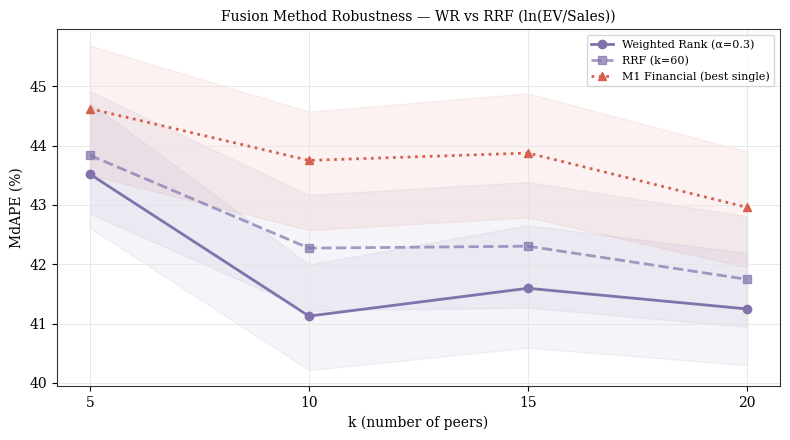

Saved: /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/figures/n10_fusion_robustness.pdf


In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for model, color, marker, ls, label in [
    ('M3_Fusion',     C3, 'o', '-',  f'Weighted Rank (α={alpha_info["best_alpha"]})'),
    ('M3_Fusion_RRF', C3, 's', '--', f'RRF (k={RRF_K_CONSTANT})'),
    ('M1_Financial',  C1, '^', ':',  'M1 Financial (best single)'),
]:
    sub = results_df[(results_df['model']==model) &
                     (results_df['multiple']=='ln_v2s')].sort_values('k')
    ax.plot(sub['k'], sub['mdape']*100, color=color, marker=marker,
            linewidth=2, markersize=6, linestyle=ls, label=label,
            alpha=0.7 if 'RRF' in model else 1.0)
    ax.fill_between(sub['k'], sub['ci_lo']*100, sub['ci_hi']*100,
                    alpha=0.08, color=color)

ax.set_xlabel('k (number of peers)')
ax.set_ylabel('MdAPE (%)')
ax.set_title('Fusion Method Robustness — WR vs RRF (ln(EV/Sales))', fontsize=10)
ax.set_xticks(K_ROBUSTNESS)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / 'n10_fusion_robustness.pdf', dpi=FIGURE_DPI)
plt.show()
print(f"Saved: {FIGURES / 'n10_fusion_robustness.pdf'}")


## 4. Hypothesis Tests (H1, H2, H3)

One-sided Wilcoxon signed-rank test on matched firm-level APE differences.

| Hypothesis | Comparison | Claim |
|---|---|---|
| H1 | M1 vs M0 | Financial similarity > industry membership |
| H2 | M2 vs M0 | Text similarity > industry membership |
| H3 | M3 vs best single | Fusion > either modality alone |

### 4.1 H1 — Financial kNN beats FF49

In [11]:
print("=" * 70)
print("H1: Financial kNN (M1) outperforms FF49 Baseline (M0)")
print("=" * 70)

for mult_col, mult_label in MULTIPLES_EVAL:
    e0 = errors_store[('M0_FF49',      mult_col, K_MAIN)]
    e1 = errors_store[('M1_Financial', mult_col, K_MAIN)]

    merged = e0.merge(e1, on=['focal_tic','focal_fyear'], suffixes=('_m0','_m1'))
    stat, pval = wilcoxon(merged['ape_m0'], merged['ape_m1'], alternative='greater')

    m0_mdape = results_df[(results_df['model']=='M0_FF49') &
                          (results_df['multiple']==mult_col) &
                          (results_df['k']==K_MAIN)]['mdape'].values[0]
    m1_mdape = results_df[(results_df['model']=='M1_Financial') &
                          (results_df['multiple']==mult_col) &
                          (results_df['k']==K_MAIN)]['mdape'].values[0]
    imp = (m0_mdape - m1_mdape) / m0_mdape * 100

    sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else 'n.s.'
    print(f"\n  {mult_label}:")
    print(f"    M0={m0_mdape*100:.2f}%  M1={m1_mdape*100:.2f}%  "
          f"Δ={imp:+.1f}%  p={pval:.4f} {sig}")


H1: Financial kNN (M1) outperforms FF49 Baseline (M0)

  ln(EV/Sales):
    M0=54.79%  M1=43.75%  Δ=+20.2%  p=0.0000 ***

  ln(EV/Assets):
    M0=82.31%  M1=68.60%  Δ=+16.7%  p=0.0000 ***

  ln(MktCap/SEQ):
    M0=60.06%  M1=50.43%  Δ=+16.0%  p=0.0000 ***


### 4.2 H2 — Text kNN beats FF49

In [12]:
print("=" * 70)
print("H2: Text kNN (M2) outperforms FF49 Baseline (M0)")
print("=" * 70)

for mult_col, mult_label in MULTIPLES_EVAL:
    e0 = errors_store[('M0_FF49', mult_col, K_MAIN)]
    e2 = errors_store[('M2_Text', mult_col, K_MAIN)]
    merged = e0.merge(e2, on=['focal_tic','focal_fyear'], suffixes=('_m0','_m2'))
    stat, pval = wilcoxon(merged['ape_m0'], merged['ape_m2'], alternative='greater')

    m0_mdape = results_df[(results_df['model']=='M0_FF49') &
                          (results_df['multiple']==mult_col) &
                          (results_df['k']==K_MAIN)]['mdape'].values[0]
    m2_mdape = results_df[(results_df['model']=='M2_Text') &
                          (results_df['multiple']==mult_col) &
                          (results_df['k']==K_MAIN)]['mdape'].values[0]
    imp = (m0_mdape - m2_mdape) / m0_mdape * 100
    sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else 'n.s.'
    print(f"\n  {mult_label}:")
    print(f"    M0={m0_mdape*100:.2f}%  M2={m2_mdape*100:.2f}%  "
          f"Δ={imp:+.1f}%  p={pval:.4f} {sig}")


H2: Text kNN (M2) outperforms FF49 Baseline (M0)

  ln(EV/Sales):
    M0=54.79%  M2=51.89%  Δ=+5.3%  p=0.0000 ***

  ln(EV/Assets):
    M0=82.31%  M2=76.53%  Δ=+7.0%  p=0.0004 ***

  ln(MktCap/SEQ):
    M0=60.06%  M2=55.87%  Δ=+7.0%  p=0.0000 ***


### 4.3 H3 — Fusion beats best single modality

In [13]:
print("=" * 70)
print("H3: Fusion (M3) outperforms best single modality")
print("=" * 70)

for mult_col, mult_label in MULTIPLES_EVAL:
    m1_mdape = results_df[(results_df['model']=='M1_Financial') &
                          (results_df['multiple']==mult_col) &
                          (results_df['k']==K_MAIN)]['mdape'].values[0]
    m2_mdape = results_df[(results_df['model']=='M2_Text') &
                          (results_df['multiple']==mult_col) &
                          (results_df['k']==K_MAIN)]['mdape'].values[0]
    m3_mdape = results_df[(results_df['model']=='M3_Fusion') &
                          (results_df['multiple']==mult_col) &
                          (results_df['k']==K_MAIN)]['mdape'].values[0]

    best_single      = min(m1_mdape, m2_mdape)
    best_single_name = 'M1' if m1_mdape < m2_mdape else 'M2'
    imp = (best_single - m3_mdape) / best_single * 100

    e_best = errors_store[('M1_Financial' if best_single_name=='M1' else 'M2_Text',
                            mult_col, K_MAIN)]
    e3     = errors_store[('M3_Fusion', mult_col, K_MAIN)]
    merged = e_best.merge(e3, on=['focal_tic','focal_fyear'],
                          suffixes=('_best','_m3'))
    stat, pval = wilcoxon(merged['ape_best'], merged['ape_m3'], alternative='greater')
    sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else 'n.s.'

    print(f"\n  {mult_label}:")
    print(f"    Best single ({best_single_name})={best_single*100:.2f}%  "
          f"M3={m3_mdape*100:.2f}%  Δ={imp:+.1f}%  p={pval:.4f} {sig}")

print(f"\n  RRF robustness check (ln_v2s, k={K_MAIN}):")
m3_wr  = results_df[(results_df['model']=='M3_Fusion') &
                    (results_df['multiple']=='ln_v2s') &
                    (results_df['k']==K_MAIN)]['mdape'].values[0]
m3_rrf = results_df[(results_df['model']=='M3_Fusion_RRF') &
                    (results_df['multiple']=='ln_v2s') &
                    (results_df['k']==K_MAIN)]['mdape'].values[0]
print(f"    M3 (WR)  = {m3_wr*100:.3f}%")
print(f"    M3 (RRF) = {m3_rrf*100:.3f}%")
print(f"    Difference = {abs(m3_wr-m3_rrf)*100:.3f}pp")


H3: Fusion (M3) outperforms best single modality

  ln(EV/Sales):
    Best single (M1)=43.75%  M3=41.13%  Δ=+6.0%  p=0.0000 ***

  ln(EV/Assets):
    Best single (M1)=68.60%  M3=66.29%  Δ=+3.4%  p=0.0000 ***

  ln(MktCap/SEQ):
    Best single (M1)=50.43%  M3=49.04%  Δ=+2.8%  p=0.0000 ***

  RRF robustness check (ln_v2s, k=10):
    M3 (WR)  = 41.127%
    M3 (RRF) = 42.272%
    Difference = 1.145pp


## 5. Annual Breakdown

MdAPE by fiscal year for each model, with the 2022 rate-normalisation shock
marked.

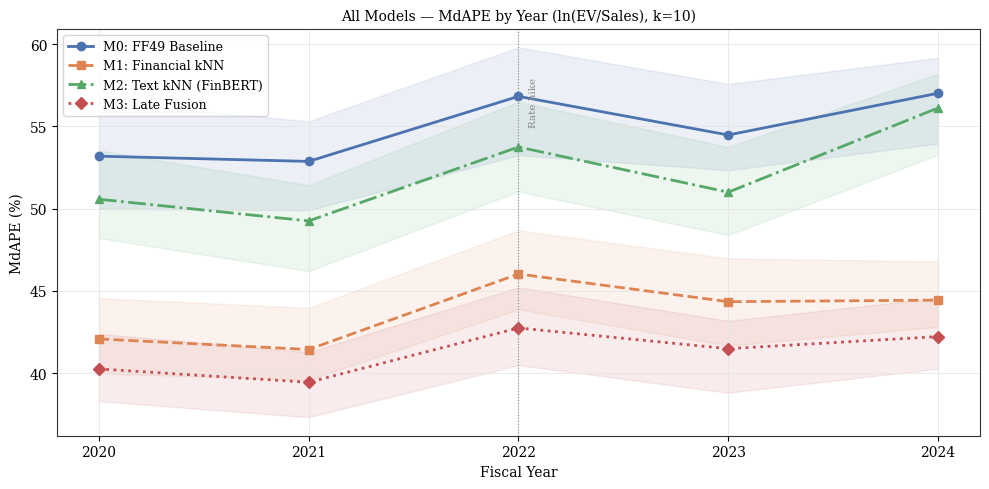

Saved: /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/figures/n10_all_models_by_year.pdf


In [14]:
MODELS_PLOT = [
    ('M0_FF49',      peers_m0, C['M0_FF49'],      'o', '-'),
    ('M1_Financial', peers_m1, C['M1_Financial'], 's', '--'),
    ('M2_Text',      peers_m2, C['M2_Text'],      '^', '-.'),
    ('M3_Fusion',    peers_m3, C['M3_Fusion'],    'D', ':'),
]

annual = []
for yr in YEARS:
    for model_name, peers_df, color, marker, ls in MODELS_PLOT:
        peers_yr = peers_df[peers_df['focal_fyear']==yr]
        mult_yr  = multiples[multiples['fyear']==yr]
        err = compute_mdape(peers_yr, mult_yr, 'ln_v2s', K_MAIN)
        if len(err) > 10:
            rng   = np.random.RandomState(RANDOM_SEED)
            boots = [np.median(rng.choice(err['ape'].values, len(err), replace=True))
                     for _ in range(500)]
            annual.append({
                'model': model_name, 'fyear': yr,
                'mdape': np.median(err['ape']),
                'ci_lo': np.percentile(boots, 2.5),
                'ci_hi': np.percentile(boots, 97.5),
            })

ann_df = pd.DataFrame(annual)

fig, ax = plt.subplots(figsize=(10, 5))
for model_name, peers_df, color, marker, ls in MODELS_PLOT:
    sub = ann_df[ann_df['model']==model_name].sort_values('fyear')
    ax.plot(sub['fyear'], sub['mdape']*100, color=color, marker=marker,
            linewidth=2, markersize=6, linestyle=ls,
            label=MODEL_LABELS[model_name])
    ax.fill_between(sub['fyear'], sub['ci_lo']*100, sub['ci_hi']*100,
                    alpha=0.10, color=color)

ax.axvline(2022, color='#888888', linewidth=0.8, linestyle=':')
ax.text(2022.05, ann_df['ci_hi'].max()*100*0.97,
        'Rate hike', fontsize=7.5, color='#888888', rotation=90, va='top')
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('MdAPE (%)')
ax.set_title(f'All Models — MdAPE by Year (ln(EV/Sales), k={K_MAIN})', fontsize=10)
ax.set_xticks(YEARS)
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES / 'n10_all_models_by_year.pdf', dpi=FIGURE_DPI)
plt.show()
print(f"Saved: {FIGURES / 'n10_all_models_by_year.pdf'}")


In [15]:
# Per-year MdAPE table with gap columns
print("Per-year MdAPE breakdown — ln(EV/Sales), k=10")
print("=" * 70)
print(f"{'Year':<6} {'M0':>8} {'M1':>8} {'M2':>8} {'M3':>8} "
      f"{'M1-M0':>8} {'M2-M1':>8} {'M3-M1':>8}")
print("-" * 70)

for year in YEARS:
    row = {}
    for model_name in ['M0_FF49','M1_Financial','M2_Text','M3_Fusion']:
        err = errors_store[(model_name, 'ln_v2s', K_MAIN)]
        err_yr = err[err['focal_fyear'] == year]
        row[model_name] = np.median(err_yr['ape']) * 100 if len(err_yr) > 0 else np.nan

    print(f"  {year:<4} "
          f"{row['M0_FF49']:>8.2f} "
          f"{row['M1_Financial']:>8.2f} "
          f"{row['M2_Text']:>8.2f} "
          f"{row['M3_Fusion']:>8.2f} "
          f"{row['M0_FF49']-row['M1_Financial']:>8.2f} "
          f"{row['M2_Text']-row['M1_Financial']:>8.2f} "
          f"{row['M1_Financial']-row['M3_Fusion']:>8.2f}")


Per-year MdAPE breakdown — ln(EV/Sales), k=10
Year         M0       M1       M2       M3    M1-M0    M2-M1    M3-M1
----------------------------------------------------------------------
  2020    53.19    42.08    50.57    40.26    11.11     8.49     1.82
  2021    52.87    41.44    49.25    39.45    11.43     7.81     1.99
  2022    56.82    46.03    53.75    42.75    10.79     7.72     3.28
  2023    54.48    44.35    51.00    41.49    10.13     6.65     2.86
  2024    57.01    44.44    56.12    42.23    12.57    11.68     2.21


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 5.X  FF49 Industry-Level Breakdown
# ─────────────────────────────────────────────────────────────────────────────
# For every FF49 industry with sufficient firm-years, compute MdAPE per model
# on the primary multiple (ln_v2s) at k=10. Highlights where each model wins
# and where text/fusion add value beyond the FF49 baseline.
# ─────────────────────────────────────────────────────────────────────────────

MIN_FIRMYEARS_PER_INDUSTRY = 50   # exclude thin industries from per-industry table

# Lookup focal_tic + focal_fyear -> FF49 industry
focal_industry = (df_panel[['tic', 'fyear', 'ff49_num', 'ff49_abbr']]
                  .rename(columns={'tic': 'focal_tic', 'fyear': 'focal_fyear'})
                  .drop_duplicates(['focal_tic', 'focal_fyear']))

industry_rows = []
for model_name, _ in MODELS:
    if 'RRF' in model_name:
        continue
    err = errors_store[(model_name, 'ln_v2s', K_MAIN)].copy()
    err = err.merge(focal_industry, on=['focal_tic', 'focal_fyear'], how='inner')

    for (ff49_num, ff49_abbr), grp in err.groupby(['ff49_num', 'ff49_abbr']):
        if len(grp) < MIN_FIRMYEARS_PER_INDUSTRY:
            continue
        boot = bootstrap_mdape(grp[['ape']])
        industry_rows.append({
            'ff49_num' : int(ff49_num),
            'ff49_abbr': ff49_abbr,
            'model'    : model_name,
            'mdape'    : boot['mdape'],
            'ci_lo'    : boot['ci_lo'],
            'ci_hi'    : boot['ci_hi'],
            'n'        : boot['n'],
        })

industry_df = pd.DataFrame(industry_rows)

# Wide table: industry × model -> MdAPE
industry_wide = (industry_df
                 .pivot_table(index=['ff49_num', 'ff49_abbr'],
                              columns='model', values='mdape')
                 .reset_index())

# n column from M0 (largest, since M0 covers full eval sample by industry)
n_lookup = (industry_df[industry_df['model'] == 'M0_FF49']
            [['ff49_num', 'n']]
            .rename(columns={'n': 'firm_years'}))
industry_wide = industry_wide.merge(n_lookup, on='ff49_num', how='left')

# Improvements
industry_wide['delta_M1_M0'] = industry_wide['M0_FF49']      - industry_wide['M1_Financial']
industry_wide['delta_M2_M0'] = industry_wide['M0_FF49']      - industry_wide['M2_Text']
industry_wide['delta_M3_M0'] = industry_wide['M0_FF49']      - industry_wide['M3_Fusion']
industry_wide['delta_M3_M1'] = industry_wide['M1_Financial'] - industry_wide['M3_Fusion']

industry_wide = industry_wide.sort_values('firm_years', ascending=False).reset_index(drop=True)

print("=" * 110)
print(f"FF49 INDUSTRY BREAKDOWN — MdAPE on ln(EV/Sales), k={K_MAIN}, "
      f"min {MIN_FIRMYEARS_PER_INDUSTRY} firm-years")
print("=" * 110)
print(f"  {'#':>3} {'Industry':<28} {'n':>6} "
      f"{'M0':>7} {'M1':>7} {'M2':>7} {'M3':>7} "
      f"{'ΔM3-M0':>8} {'ΔM3-M1':>8}")
print(f"  {'-' * 105}")
for _, r in industry_wide.iterrows():
    print(f"  {int(r['ff49_num']):>3} {r['ff49_abbr']:<28} {int(r['firm_years']):>6,} "
          f"{r['M0_FF49']*100:>6.1f}% {r['M1_Financial']*100:>6.1f}% "
          f"{r['M2_Text']*100:>6.1f}% {r['M3_Fusion']*100:>6.1f}% "
          f"{r['delta_M3_M0']*100:>+7.1f}pp {r['delta_M3_M1']*100:>+7.1f}pp")

industry_wide.to_csv(DATA_RESULTS / 'results_by_industry.csv', index=False)
print(f"\nSaved: {DATA_RESULTS / 'results_by_industry.csv'}")

FF49 INDUSTRY BREAKDOWN — MdAPE on ln(EV/Sales), k=10, min 50 firm-years
    # Industry                          n      M0      M1      M2      M3   ΔM3-M0   ΔM3-M1
  ---------------------------------------------------------------------------------------------------------
   45 Banks                         1,506   38.1%   37.8%   41.9%   36.5%    +1.6pp    +1.3pp
   48 Fin                           1,416   16.7%   15.7%   15.0%   14.4%    +2.3pp    +1.2pp
   13 Drugs                         1,119   47.0%   30.3%   36.9%   28.4%   +18.5pp    +1.8pp
   36 Softw                         1,102   38.4%   38.2%   41.7%   36.9%    +1.5pp    +1.2pp
   34 BusSv                           600   53.6%   44.4%   51.9%   41.3%   +12.3pp    +3.1pp
   37 Chips                           552   52.5%   44.1%   55.8%   46.9%    +5.6pp    -2.8pp
   43 Rtail                           544   81.8%   79.8%   95.5%   79.2%    +2.5pp    +0.6pp
   46 Insur                           475   99.5%   97.3%  104.0%   9

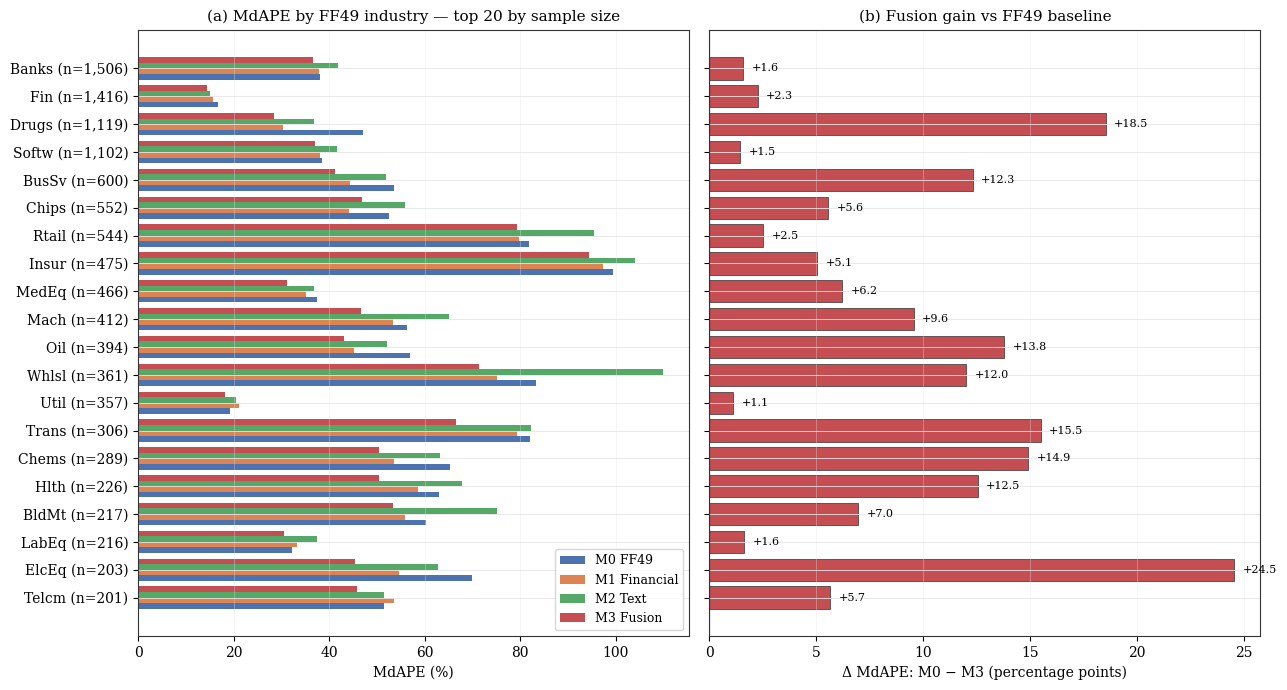

Saved: /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/figures/n10_industry_breakdown.pdf

M3 beats M0 in 34/36 industries (94%)
Largest M3 gain : Toys (+50.9pp)
Worst M3 result : Steel (-13.2pp)


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure: Top-20 industries — model performance & fusion gain over FF49
# ─────────────────────────────────────────────────────────────────────────────
top_n = 20
top_ind = industry_wide.head(top_n).iloc[::-1].copy()    # reverse for barh
labels  = [f"{a} (n={int(n):,})"
           for a, n in zip(top_ind['ff49_abbr'], top_ind['firm_years'])]

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)

ax = axes[0]
y = np.arange(len(top_ind))
h = 0.20
ax.barh(y - 1.5*h, top_ind['M0_FF49']      * 100, h, color=C['M0_FF49'],      label='M0 FF49')
ax.barh(y - 0.5*h, top_ind['M1_Financial'] * 100, h, color=C['M1_Financial'], label='M1 Financial')
ax.barh(y + 0.5*h, top_ind['M2_Text']      * 100, h, color=C['M2_Text'],      label='M2 Text')
ax.barh(y + 1.5*h, top_ind['M3_Fusion']    * 100, h, color=C['M3_Fusion'],    label='M3 Fusion')
ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_xlabel('MdAPE (%)')
ax.set_title(f'(a) MdAPE by FF49 industry — top {top_n} by sample size')
ax.legend(loc='lower right', frameon=True)
ax.grid(axis='x', alpha=0.4)

ax = axes[1]
delta = top_ind['delta_M3_M0'] * 100
colors = [C['M3_Fusion'] if d > 0 else CGREY for d in delta]
ax.barh(y, delta, color=colors, edgecolor='#333', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Δ MdAPE: M0 − M3 (percentage points)')
ax.set_title('(b) Fusion gain vs FF49 baseline')
ax.grid(axis='x', alpha=0.4)
for yi, d in zip(y, delta):
    ax.text(d + (0.4 if d >= 0 else -0.4), yi,
            f'{d:+.1f}', va='center',
            ha='left' if d >= 0 else 'right', fontsize=8)

plt.tight_layout()
fig_path = FIGURES / f"n10_industry_breakdown.{FIGURE_FORMAT}"
plt.savefig(fig_path)
plt.show()
print(f"Saved: {fig_path}")

# Headline numbers for prose
won_by_m3 = (industry_wide['delta_M3_M0'] > 0).sum()
total     = len(industry_wide)
print(f"\nM3 beats M0 in {won_by_m3}/{total} industries "
      f"({won_by_m3/total*100:.0f}%)")
print(f"Largest M3 gain : {industry_wide['ff49_abbr'].iloc[industry_wide['delta_M3_M0'].argmax()]} "
      f"({industry_wide['delta_M3_M0'].max()*100:+.1f}pp)")
print(f"Worst M3 result : {industry_wide['ff49_abbr'].iloc[industry_wide['delta_M3_M0'].argmin()]} "
      f"({industry_wide['delta_M3_M0'].min()*100:+.1f}pp)")

### 5.5.X Peer Coherence Diagnostics

The methodology chapter (§4.6.2) defines two peer-set quality diagnostics that
complement MdAPE: **peer-to-focal similarity** (how close, on average, are the
top-$k$ peers to the focal firm) and **peer-to-peer coherence** (how tightly
clustered the peers are among themselves). Both are computed in two geometries —
the 64-dimensional financial space used by M1 and the 768-dimensional FinBERT
text space used by M2 — so each model can be evaluated in the dimension it
optimises against and in the dimension it does not.

The results below report these four quantities (focal–peer × peer–peer ×
financial × text) at $k=10$ on the evaluation sample. The hypothesis is that
each model produces tight clusters in its own modality and looser ones in the
other; M3, by construction, should sit between M1 and M2 on both axes.

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# Peer coherence diagnostics — focal-peer & peer-peer similarity in both spaces
# Reports M0/M1/M2/M3 on a 2×2 grid: {focal-peer, peer-peer} × {financial, text}
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import normalize

# 1. Build feature matrices (one per geometry), one row per (tic, fyear)
print("Loading feature matrices...")
fin = pd.read_parquet(FINANCIALS_NORM)
with open(SELECTED_FEATURES_FILE) as f:
    feat_cols = json.load(f)['selected_features']

fin_keys = fin[['tic', 'fyear']].copy()
fin_X    = fin[feat_cols].fillna(0).values
fin_X    = normalize(fin_X, norm='l2', axis=1)        # cosine == dot post-L2
fin_idx  = {(t, int(y)): i for i, (t, y) in enumerate(zip(fin_keys['tic'],
                                                           fin_keys['fyear']))}

emb = pd.read_parquet(EMBEDDINGS)
# robust column detection — embeddings stored as dim_0..dim_767
emb_dim_cols = [c for c in emb.columns if c not in ('tic', 'fyear')]
emb_X    = emb[emb_dim_cols].values.astype(np.float32)
emb_X    = normalize(emb_X, norm='l2', axis=1)
emb_idx  = {(t, int(y)): i for i, (t, y) in enumerate(zip(emb['tic'],
                                                           emb['fyear']))}

print(f"  Financial : {fin_X.shape[0]:,} rows × {fin_X.shape[1]} dims")
print(f"  Text      : {emb_X.shape[0]:,} rows × {emb_X.shape[1]} dims")


def coherence_for_model(peers_df, k):
    """Mean focal-peer & peer-peer cosine in both spaces, per focal firm-year."""
    peers_k = (peers_df[peers_df['rank'] <= k]
               if peers_df['rank'].max() > 1 else peers_df).copy()

    rows = []
    grouped = peers_k.groupby(['focal_tic', 'focal_fyear'])
    for (focal_tic, focal_year), grp in grouped:
        focal_year = int(focal_year)
        peer_tics  = grp['peer_tic'].tolist()
        if len(peer_tics) < 2:
            continue

        for space, X, lookup in [('fin', fin_X, fin_idx),
                                  ('txt', emb_X, emb_idx)]:
            f_key = (focal_tic, focal_year)
            p_keys = [(p, focal_year) for p in peer_tics]
            f_idx_v = lookup.get(f_key)
            p_idx_v = [lookup[k_] for k_ in p_keys if k_ in lookup]
            if f_idx_v is None or len(p_idx_v) < 2:
                continue

            f_vec  = X[f_idx_v]
            p_vecs = X[p_idx_v]

            # focal-peer: mean cosine of focal vs each peer
            focal_peer = float((p_vecs @ f_vec).mean())
            # peer-peer: mean of upper-triangle of peer×peer cosine
            P = p_vecs @ p_vecs.T
            iu = np.triu_indices(len(p_vecs), k=1)
            peer_peer = float(P[iu].mean())

            rows.append({
                'focal_tic'  : focal_tic,
                'focal_fyear': focal_year,
                'space'      : space,
                'focal_peer' : focal_peer,
                'peer_peer'  : peer_peer,
            })
    return pd.DataFrame(rows)


coherence = {}
for model_name, peers_df in MODELS:
    if 'RRF' in model_name:
        continue
    print(f"  computing coherence for {model_name}...")
    coherence[model_name] = coherence_for_model(peers_df, K_MAIN)

# 2. Aggregate to model × space → mean focal-peer & peer-peer
agg_rows = []
for model_name, df in coherence.items():
    for space in ['fin', 'txt']:
        sub = df[df['space'] == space]
        agg_rows.append({
            'Model'     : model_name,
            'Space'     : 'Financial' if space == 'fin' else 'Text',
            'Focal-Peer': sub['focal_peer'].mean(),
            'Peer-Peer' : sub['peer_peer'].mean(),
            'n'         : len(sub),
        })
coh_df = pd.DataFrame(agg_rows)

print("\n" + "=" * 86)
print(f"PEER COHERENCE — k={K_MAIN}, eval sample, mean cosine similarity")
print("=" * 86)
for space_label in ['Financial', 'Text']:
    print(f"\n  {space_label} space:")
    print(f"    {'Model':<16} {'Focal-Peer':>12} {'Peer-Peer':>12} {'n':>8}")
    print(f"    {'-' * 52}")
    for _, r in coh_df[coh_df['Space'] == space_label].iterrows():
        print(f"    {r['Model']:<16} {r['Focal-Peer']:>12.3f} "
              f"{r['Peer-Peer']:>12.3f} {r['n']:>8,}")

coh_df.to_csv(DATA_RESULTS / 'peer_coherence.csv', index=False)
print(f"\nSaved: {DATA_RESULTS / 'peer_coherence.csv'}")

Loading feature matrices...
  Financial : 20,883 rows × 64 dims
  Text      : 13,559 rows × 768 dims
  computing coherence for M0_FF49...
  computing coherence for M1_Financial...
  computing coherence for M2_Text...
  computing coherence for M3_Fusion...

PEER COHERENCE — k=10, eval sample, mean cosine similarity

  Financial space:
    Model              Focal-Peer    Peer-Peer        n
    ----------------------------------------------------
    M0_FF49                 0.215        0.215   13,550
    M1_Financial            0.767        0.704   13,559
    M2_Text                 0.299        0.279   13,559
    M3_Fusion               0.648        0.507   13,559

  Text space:
    Model              Focal-Peer    Peer-Peer        n
    ----------------------------------------------------
    M0_FF49                 0.951        0.951   13,550
    M1_Financial            0.945        0.944   13,559
    M2_Text                 0.977        0.974   13,559
    M3_Fusion               0.9

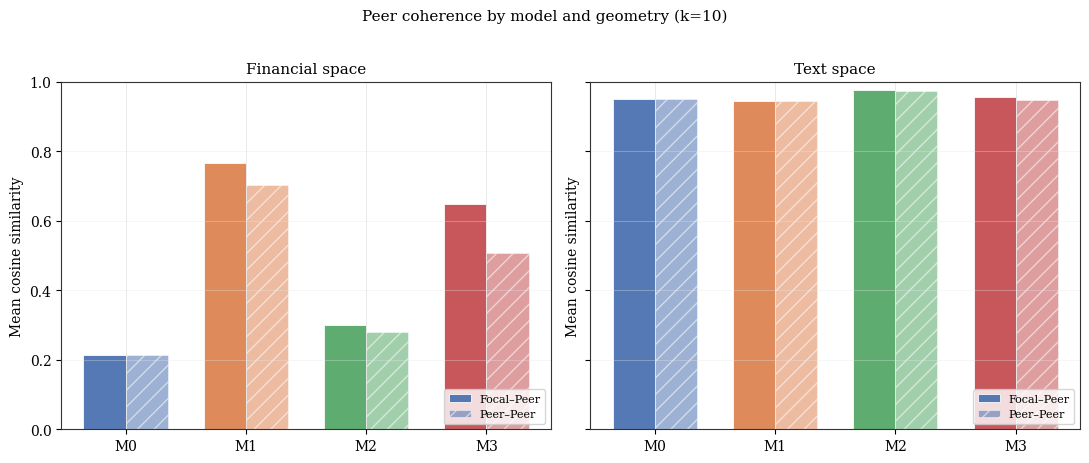

Saved: /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/figures/n10_peer_coherence.pdf


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure: 2×2 grid of coherence — each model × {focal-peer, peer-peer} × space
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

models_in_order = ['M0_FF49', 'M1_Financial', 'M2_Text', 'M3_Fusion']
x = np.arange(len(models_in_order))
w = 0.35

for ax, space_label in zip(axes, ['Financial', 'Text']):
    sub = coh_df[coh_df['Space'] == space_label].set_index('Model').loc[models_in_order]
    ax.bar(x - w/2, sub['Focal-Peer'], w,
           color=[C[m] for m in models_in_order], alpha=0.95,
           edgecolor='white', linewidth=0.6, label='Focal–Peer')
    ax.bar(x + w/2, sub['Peer-Peer'], w,
           color=[C[m] for m in models_in_order], alpha=0.55,
           edgecolor='white', linewidth=0.6, label='Peer–Peer', hatch='//')
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m].split(':')[0] for m in models_in_order],
                       rotation=0)
    ax.set_title(f'{space_label} space')
    ax.set_ylabel('Mean cosine similarity')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.4)
    ax.legend(loc='lower right', frameon=True, fontsize=8)

plt.suptitle(f'Peer coherence by model and geometry (k={K_MAIN})',
             fontsize=11, y=1.02)
plt.tight_layout()
fig_path = FIGURES / f"n10_peer_coherence.{FIGURE_FORMAT}"
plt.savefig(fig_path)
plt.show()
print(f"Saved: {fig_path}")

### 5.X.X Failure Analysis: Where Does Late Fusion Break Down?

Aggregate MdAPE statistics summarise central tendency but obscure the
right tail. Section §6.5 noted Amazon as a structural outlier whose
EV/Sales multiple no peer median can reasonably reach. To formalise this
intuition we examine the worst-1% of focal firm-years under M3 — the
cases where late fusion fails — and characterise them along four
dimensions: market-cap decile, R&D-disclosure regime, FF49 industry,
and 10-K summary word count.

Three failure modes are anticipated. First, **structural outliers**
(Amazon, Tesla, Netflix in growth phases) trade at multiples no peer
median can match regardless of peer-set quality. Second, **thin-text
firms** with summaries near the 50-character minimum supply M2 with
weak signal. Third, **size-boundary firms** sit just above the
\$50M-market-cap filter and have few size-comparable peers in the eval
sample. The table below reports, for each failure mode, its share among
the worst 1% of M3 firm-years and its share in the full eval sample —
a ratio greater than one indicates over-representation.

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# Failure analysis — worst 1% of focal firm-years under M3
# Characterise along: size decile, R&D regime, FF49, summary word count
# ─────────────────────────────────────────────────────────────────────────────
WORST_PCT = 0.01

# 1. Per-firm-year APE under M3
m3_err = errors_store[('M3_Fusion', 'ln_v2s', K_MAIN)].copy()
m3_err = m3_err.rename(columns={'focal_tic': 'tic', 'focal_fyear': 'fyear'})

# 2. Attach characteristics from panel (size, xrd, ff49, sic)
char = pd.read_parquet(
    PANEL_CLEAN,
    columns=['tic', 'fyear', 'csho', 'prcc_f', 'xrd', 'sale',
             'ff49_num', 'ff49_abbr', 'sic']
).copy()
char['market_cap'] = char['csho'] * char['prcc_f']

# 3. Size decile per fyear
char['size_decile'] = (char.groupby('fyear')['market_cap']
                            .transform(lambda s: pd.qcut(s, 10,
                                                          labels=False,
                                                          duplicates='drop') + 1))

# 4. R&D regime
char['rd_regime'] = np.where(char['xrd'].fillna(0) > 0, 'R&D-Active', 'R&D-Zero')

# 5. Summary word count
summary_wc = []
for yr, path in SUMMARIES_FILES.items():
    if not path.exists():
        continue
    s = pd.read_csv(path)
    s = s[s['business_description'].notna() &
          ~s['business_description'].isin(['ERROR', 'INSUFFICIENT_DATA',
                                              'ERROR_EXTRACTING_TEXT'])]
    s['word_count'] = s['business_description'].str.split().str.len()
    s['fyear'] = int(yr)
    summary_wc.append(s[['tic', 'fyear', 'word_count']])
summary_wc = pd.concat(summary_wc, ignore_index=True)

# 6. Merge it all
m3_err = m3_err.merge(char, on=['tic', 'fyear'], how='left')
m3_err = m3_err.merge(summary_wc, on=['tic', 'fyear'], how='left')

# 7. Worst 1% by APE
threshold = m3_err['ape'].quantile(1 - WORST_PCT)
worst = m3_err[m3_err['ape'] >= threshold].copy()
n_worst = len(worst)
n_full  = len(m3_err)

print("=" * 90)
print(f"FAILURE ANALYSIS — worst {WORST_PCT*100:.0f}% of focal firm-years under M3")
print("=" * 90)
print(f"  APE threshold (top-{WORST_PCT*100:.0f}%): {threshold*100:.1f}%")
print(f"  n worst: {n_worst:,}   n full eval sample: {n_full:,}")

# ── Failure mode 1: structural outliers (top 3 deciles by size + extreme APE) ──
print(f"\n  Failure mode 1 — Size profile of worst firms:")
print(f"    {'Decile':<8} {'Worst share':>12} {'Full share':>12} {'Over-rep':>10}")
print(f"    {'-' * 48}")
for d in sorted(worst['size_decile'].dropna().unique().astype(int)):
    w_share = (worst['size_decile'] == d).sum() / n_worst
    f_share = (m3_err['size_decile'] == d).sum() / n_full
    over    = w_share / f_share if f_share > 0 else np.nan
    print(f"    {int(d):<8} {w_share*100:>11.1f}% {f_share*100:>11.1f}% "
          f"{over:>9.2f}x")

# ── Failure mode 2: R&D regime ─────────────────────────────────────────────
print(f"\n  Failure mode 2 — R&D regime of worst firms:")
for regime in ['R&D-Active', 'R&D-Zero']:
    w_share = (worst['rd_regime'] == regime).sum() / n_worst
    f_share = (m3_err['rd_regime'] == regime).sum() / n_full
    over    = w_share / f_share if f_share > 0 else np.nan
    print(f"    {regime:<14} worst={w_share*100:>5.1f}%  "
          f"full={f_share*100:>5.1f}%  over-rep={over:.2f}x")

# ── Failure mode 3: thin-text (summary < 200 words) ────────────────────────
thin_thresh = 200
worst_thin  = (worst['word_count'] < thin_thresh).sum()
full_thin   = (m3_err['word_count'] < thin_thresh).sum()
print(f"\n  Failure mode 3 — Thin-text (summary < {thin_thresh} words):")
print(f"    Worst-1%: {worst_thin/n_worst*100:>5.1f}%  ({worst_thin:,} firms)")
print(f"    Full    : {full_thin/n_full*100:>5.1f}%  ({full_thin:,} firms)")
print(f"    Over-representation: "
      f"{(worst_thin/n_worst)/(full_thin/n_full):.2f}x")

# ── Top FF49 industries among the worst ────────────────────────────────────
print(f"\n  Top FF49 industries in worst-1% (showing share ≥ 3%):")
ff49_worst = (worst['ff49_abbr'].value_counts(normalize=True) * 100).head(10)
ff49_full  = (m3_err['ff49_abbr'].value_counts(normalize=True) * 100)
for ind, w_pct in ff49_worst.items():
    if w_pct < 3.0:
        continue
    f_pct = ff49_full.get(ind, 0)
    over  = w_pct / f_pct if f_pct > 0 else np.nan
    print(f"    {ind:<28} worst={w_pct:>5.1f}%  full={f_pct:>5.1f}%  "
          f"over-rep={over:.2f}x")

# ── Top 20 named worst firms ───────────────────────────────────────────────
print(f"\n  Top 20 worst firm-years (by APE under M3):")
top20 = worst.nlargest(20, 'ape')[
    ['tic', 'fyear', 'ape', 'market_cap', 'rd_regime', 'word_count', 'ff49_abbr']
]
print(f"    {'Tic':<7} {'Year':>5} {'APE':>7} {'Mkt Cap $M':>11} "
      f"{'R&D':<11} {'Words':>6} {'Industry':<22}")
print(f"    {'-' * 80}")
for _, r in top20.iterrows():
    print(f"    {r['tic']:<7} {int(r['fyear']):>5} "
          f"{r['ape']*100:>6.0f}% {r['market_cap']:>11,.0f} "
          f"{r['rd_regime']:<11} {int(r['word_count']) if pd.notna(r['word_count']) else 0:>6} "
          f"{r['ff49_abbr']:<22}")

worst.to_csv(DATA_RESULTS / 'failure_analysis_worst1pct.csv', index=False)
print(f"\nSaved: {DATA_RESULTS / 'failure_analysis_worst1pct.csv'}")

FAILURE ANALYSIS — worst 1% of focal firm-years under M3
  APE threshold (top-1%): 2829.1%
  n worst: 136   n full eval sample: 13,559

  Failure mode 1 — Size profile of worst firms:
    Decile    Worst share   Full share   Over-rep
    ------------------------------------------------
    1               11.0%         8.3%      1.33x
    2               11.0%         9.0%      1.22x
    3               10.3%         9.7%      1.06x
    4               11.0%         9.8%      1.13x
    5               11.8%        10.2%      1.16x
    6               16.2%        10.7%      1.51x
    7                8.8%        11.1%      0.79x
    8               11.0%        10.7%      1.03x
    9                5.9%        10.4%      0.57x
    10               2.9%        10.1%      0.29x

  Failure mode 2 — R&D regime of worst firms:
    R&D-Active     worst= 41.2%  full= 41.9%  over-rep=0.98x
    R&D-Zero       worst= 58.8%  full= 58.1%  over-rep=1.01x

  Failure mode 3 — Thin-text (summary < 200

So What?

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# 6.X  Economic Significance — dollar EV implied by each peer set
# ─────────────────────────────────────────────────────────────────────────────
# For each focal firm-year, "warranted EV" = peer-median (EV/Sales) × focal Sales.
# Dollar valuation gap |Warranted EV − Actual EV| translates the MdAPE
# improvement into M&A / IPO / fairness-opinion-relevant magnitudes.
# ─────────────────────────────────────────────────────────────────────────────

# Need the *raw* (un-logged) ev_sales multiple plus focal-firm sale, mkt cap, EV
# We rebuild from the panel because multiples.parquet stores log values only.
panel_full = pd.read_parquet(
    PANEL_CLEAN,
    columns=['tic', 'fyear', 'sale', 'at', 'csho', 'prcc_f',
             'dltt', 'dlc', 'che', 'seq', 'ff49_num', 'ff49_abbr', 'industry']
).copy()

panel_full['market_cap'] = panel_full['csho'] * panel_full['prcc_f']
panel_full['ev']         = panel_full['market_cap'] + panel_full['dltt'].fillna(0) \
                                                    + panel_full['dlc'].fillna(0) \
                                                    - panel_full['che'].fillna(0)
panel_full['ev_sales_raw'] = panel_full['ev'] / panel_full['sale']

# Winsorise raw multiple at 1/99 per fyear (consistent with N4)
panel_full['ev_sales_w'] = panel_full['ev_sales_raw'].copy()
for yr, sub in panel_full.groupby('fyear'):
    lo, hi = sub['ev_sales_raw'].quantile([0.01, 0.99])
    mask = panel_full['fyear'] == yr
    panel_full.loc[mask, 'ev_sales_w'] = panel_full.loc[mask, 'ev_sales_raw'].clip(lo, hi)

# Restrict to evaluation sample
panel_full = panel_full[panel_full.apply(
    lambda r: (r['tic'], int(r['fyear'])) in summary_tickers, axis=1
)].copy()

print(f"Eval-sample firm-years with usable EV: {panel_full['ev'].gt(0).sum():,}")


def warranted_ev(peers_df, panel_df, k):
    """Predict EV from peer-median EV/Sales × focal Sales."""
    peers_k = (peers_df[peers_df['rank'] <= k]
               if peers_df['rank'].max() > 1 else peers_df).copy()

    peer_mult = (panel_df[['tic', 'fyear', 'ev_sales_w']]
                 .rename(columns={'tic': 'peer_tic',
                                  'fyear': 'focal_fyear',
                                  'ev_sales_w': 'peer_mult'})
                 .dropna())

    peers_k = peers_k.merge(peer_mult, on=['peer_tic', 'focal_fyear'], how='inner')
    pred    = (peers_k.groupby(['focal_tic', 'focal_fyear'])['peer_mult']
                      .median().reset_index()
                      .rename(columns={'peer_mult': 'pred_mult'}))

    focal = panel_df[['tic', 'fyear', 'sale', 'ev', 'market_cap',
                      'ff49_abbr', 'industry']].rename(
        columns={'tic': 'focal_tic', 'fyear': 'focal_fyear'})
    pred  = pred.merge(focal, on=['focal_tic', 'focal_fyear'], how='inner')

    pred['warranted_ev']  = pred['pred_mult'] * pred['sale']
    pred['ev_gap_usd']    = pred['warranted_ev'] - pred['ev']
    pred['ev_gap_abs']    = pred['ev_gap_usd'].abs()
    pred['ev_gap_pct']    = pred['ev_gap_usd'] / pred['ev']
    return pred


# Compute warranted EV for each model (k = K_MAIN)
warranted = {}
for model_name, peers_df in MODELS:
    if 'RRF' in model_name:
        continue
    warranted[model_name] = warranted_ev(peers_df, panel_full, K_MAIN)
    print(f"  {model_name}: {len(warranted[model_name]):,} firm-years priced")

Eval-sample firm-years with usable EV: 13,559
  M0_FF49: 13,558 firm-years priced
  M1_Financial: 13,559 firm-years priced
  M2_Text: 13,559 firm-years priced
  M3_Fusion: 13,559 firm-years priced


In [22]:
agg_rows = []
for model_name in ['M0_FF49', 'M1_Financial', 'M2_Text', 'M3_Fusion']:
    df = warranted[model_name].dropna(subset=['ev_gap_usd', 'ev'])
    df = df[df['ev'] > 0]
    agg_rows.append({
        'Model'                 : model_name,
        'Firm-years priced'     : len(df),
        'Mean |gap| ($M)'       : df['ev_gap_abs'].mean(),
        'Median |gap| ($M)'     : df['ev_gap_abs'].median(),
        'Mean |gap| / EV (%)'   : df['ev_gap_abs'].div(df['ev']).mean()   * 100,
        'Median |gap| / EV (%)' : df['ev_gap_abs'].div(df['ev']).median() * 100,
        'Sum |gap| ($B)'        : df['ev_gap_abs'].sum() / 1e3,   # $M -> $B
    })

agg_df = pd.DataFrame(agg_rows).set_index('Model')
print("=" * 92)
print(f"PORTFOLIO-LEVEL DOLLAR MAGNITUDES — k={K_MAIN}, eval sample")
print("=" * 92)
print(agg_df.round(1).to_string())

m0_total = agg_df.loc['M0_FF49',      'Sum |gap| ($B)']
m1_total = agg_df.loc['M1_Financial', 'Sum |gap| ($B)']
m2_total = agg_df.loc['M2_Text',      'Sum |gap| ($B)']
m3_total = agg_df.loc['M3_Fusion',    'Sum |gap| ($B)']

print(f"\nTotal absolute valuation error:")
print(f"  M0 FF49      : ${m0_total:>10,.0f}B")
print(f"  M1 Financial : ${m1_total:>10,.0f}B   "
      f"(reduction vs M0: ${m0_total - m1_total:>7,.0f}B, "
      f"{(m0_total - m1_total)/m0_total*100:>5.1f}%)")
print(f"  M2 Text      : ${m2_total:>10,.0f}B   "
      f"(reduction vs M0: ${m0_total - m2_total:>7,.0f}B, "
      f"{(m0_total - m2_total)/m0_total*100:>5.1f}%)")
print(f"  M3 Fusion    : ${m3_total:>10,.0f}B   "
      f"(reduction vs M0: ${m0_total - m3_total:>7,.0f}B, "
      f"{(m0_total - m3_total)/m0_total*100:>5.1f}%)")

m0_med = agg_df.loc['M0_FF49',      'Median |gap| ($M)']
m1_med = agg_df.loc['M1_Financial', 'Median |gap| ($M)']
m2_med = agg_df.loc['M2_Text',      'Median |gap| ($M)']
m3_med = agg_df.loc['M3_Fusion',    'Median |gap| ($M)']

print(f"\nMedian per-firm-year |valuation gap|:")
print(f"  M0 FF49      : ${m0_med:>10,.0f}M")
print(f"  M1 Financial : ${m1_med:>10,.0f}M   "
      f"(reduction vs M0: ${m0_med - m1_med:>5,.0f}M, "
      f"{(m0_med - m1_med)/m0_med*100:>5.1f}%)")
print(f"  M2 Text      : ${m2_med:>10,.0f}M   "
      f"(reduction vs M0: ${m0_med - m2_med:>5,.0f}M, "
      f"{(m0_med - m2_med)/m0_med*100:>5.1f}%)")
print(f"  M3 Fusion    : ${m3_med:>10,.0f}M   "
      f"(reduction vs M0: ${m0_med - m3_med:>5,.0f}M, "
      f"{(m0_med - m3_med)/m0_med*100:>5.1f}%)")

agg_df.to_csv(DATA_RESULTS / 'economic_significance_aggregate.csv')

PORTFOLIO-LEVEL DOLLAR MAGNITUDES — k=10, eval sample
              Firm-years priced  Mean |gap| ($M)  Median |gap| ($M)  Mean |gap| / EV (%)  Median |gap| / EV (%)  Sum |gap| ($B)
Model                                                                                                                          
M0_FF49                   13558          12286.2             1118.5                171.8                   53.5        166575.7
M1_Financial              13559           9974.2              967.2                145.4                   44.7        135239.5
M2_Text                   13559          10898.5             1064.6                183.9                   50.2        147773.0
M3_Fusion                 13559           9146.6              889.2                139.2                   42.2        124018.5

Total absolute valuation error:
  M0 FF49      : $   166,576B
  M1 Financial : $   135,240B   (reduction vs M0: $ 31,336B,  18.8%)
  M2 Text      : $   147,773B   (reduction vs 

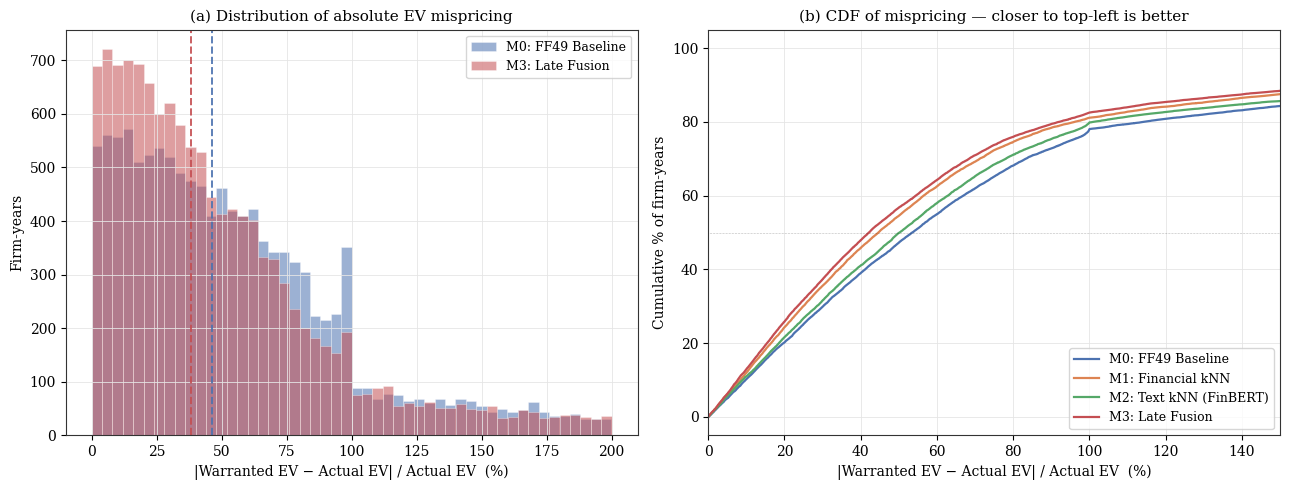

Saved: /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/figures/n10_economic_significance.pdf


In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure: Distribution of |EV gap| / EV by model — supports Eaton et al. (2022)
# bridge in Discussion §6.X (economic significance)
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel (a): |gap| / EV distribution, M0 vs M3
ax = axes[0]
for model_name, color, label in [
    ('M0_FF49',   C['M0_FF49'],   MODEL_LABELS['M0_FF49']),
    ('M3_Fusion', C['M3_Fusion'], MODEL_LABELS['M3_Fusion']),
]:
    df = warranted[model_name].dropna(subset=['ev_gap_pct'])
    df = df[df['ev'] > 0]
    pct_abs = df['ev_gap_pct'].abs() * 100
    pct_abs = pct_abs[pct_abs <= 200]
    ax.hist(pct_abs, bins=50, color=color, alpha=0.55, label=label,
            edgecolor='white', linewidth=0.4)
    ax.axvline(pct_abs.median(), color=color, linestyle='--',
               linewidth=1.4, alpha=0.9)
ax.set_xlabel('|Warranted EV − Actual EV| / Actual EV  (%)')
ax.set_ylabel('Firm-years')
ax.set_title('(a) Distribution of absolute EV mispricing')
ax.legend(loc='upper right', frameon=True)

# Panel (b): cumulative % of firms within X% mispricing
ax = axes[1]
for model_name, color, label in [
    ('M0_FF49',      C['M0_FF49'],      MODEL_LABELS['M0_FF49']),
    ('M1_Financial', C['M1_Financial'], MODEL_LABELS['M1_Financial']),
    ('M2_Text',      C['M2_Text'],      MODEL_LABELS['M2_Text']),
    ('M3_Fusion',    C['M3_Fusion'],    MODEL_LABELS['M3_Fusion']),
]:
    df = warranted[model_name].dropna(subset=['ev_gap_pct'])
    df = df[df['ev'] > 0]
    pct_abs = df['ev_gap_pct'].abs() * 100
    pct_abs = pct_abs.sort_values()
    cum = np.arange(1, len(pct_abs) + 1) / len(pct_abs) * 100
    ax.plot(pct_abs.values, cum, color=color, label=label, linewidth=1.6)
ax.set_xlim(0, 150)
ax.set_xlabel('|Warranted EV − Actual EV| / Actual EV  (%)')
ax.set_ylabel('Cumulative % of firm-years')
ax.set_title('(b) CDF of mispricing — closer to top-left is better')
ax.legend(loc='lower right', frameon=True)
ax.axhline(50, color='black', linewidth=0.4, alpha=0.5, linestyle=':')

plt.tight_layout()
fig_path = FIGURES / f"n10_economic_significance.{FIGURE_FORMAT}"
plt.savefig(fig_path)
plt.show()
print(f"Saved: {fig_path}")

## 7. Peer Set Complementarity — Jaccard Overlap M1 vs M2

Jaccard(A,B) = |A ∩ B| / |A ∪ B| measured over top-k peer lists of M1 and M2
for each focal firm-year. Low overlap indicates that financial and textual
similarity identify fundamentally different peers, providing the empirical
foundation for the fusion model M3.

In [24]:
# Build lookup dicts
m1_lookup = (peers_m1[peers_m1['rank'] <= K_MAIN]
             .groupby(['focal_tic', 'focal_fyear'])['peer_tic']
             .apply(set).to_dict())
m2_lookup = (peers_m2[peers_m2['rank'] <= K_MAIN]
             .groupby(['focal_tic', 'focal_fyear'])['peer_tic']
             .apply(set).to_dict())

# Compute Jaccard for every focal firm-year present in BOTH peer lists
all_keys = set(m1_lookup.keys()) & set(m2_lookup.keys())
print(f"Computing Jaccard for {len(all_keys):,} focal firm-years...")

records = []
for (tic, yr) in all_keys:
    m1_set = m1_lookup[(tic, yr)]
    m2_set = m2_lookup[(tic, yr)]
    union  = m1_set | m2_set
    if not union:
        continue
    records.append({
        'focal_tic'  : tic,
        'focal_fyear': yr,
        'jaccard'    : len(m1_set & m2_set) / len(union),
    })

jac_df = pd.DataFrame(records)

print(f"\n{'=' * 60}")
print(f"JACCARD OVERLAP M1 vs M2  (k={K_MAIN})")
print(f"{'=' * 60}")
print(f"  n firm-years : {len(jac_df):,}")
print(f"  Mean         : {jac_df['jaccard'].mean():.4f}")
print(f"  Median       : {jac_df['jaccard'].median():.4f}")
print(f"  Std          : {jac_df['jaccard'].std():.4f}")
print(f"  % with J=0   : {(jac_df['jaccard'] == 0).mean() * 100:.1f}%")
print(f"  % with J>0.2 : {(jac_df['jaccard'] > 0.2).mean() * 100:.1f}%")
print(f"  % with J>0.5 : {(jac_df['jaccard'] > 0.5).mean() * 100:.1f}%")

Computing Jaccard for 13,559 focal firm-years...

JACCARD OVERLAP M1 vs M2  (k=10)
  n firm-years : 13,559
  Mean         : 0.0298
  Median       : 0.0000
  Std          : 0.0515
  % with J=0   : 63.6%
  % with J>0.2 : 1.2%
  % with J>0.5 : 0.0%


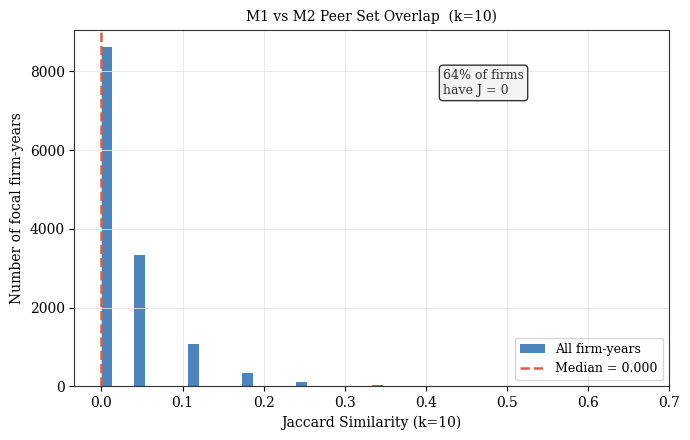

Saved: /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/figures/n10_jaccard_overlap.pdf


In [25]:
# Figure — Jaccard histogram (full eval sample)
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.hist(jac_df['jaccard'], bins=50, color='#2166ac', alpha=0.8,
        edgecolor='none', label='All firm-years')
ax.axvline(jac_df['jaccard'].median(), color='#d6604d', linewidth=1.8,
           linestyle='--',
           label=f"Median = {jac_df['jaccard'].median():.3f}")
ax.set_xlabel(f'Jaccard Similarity (k={K_MAIN})')
ax.set_ylabel('Number of focal firm-years')
ax.set_title(f'M1 vs M2 Peer Set Overlap  (k={K_MAIN})', fontsize=10)
ax.legend(fontsize=9)

pct_zero = (jac_df['jaccard'] == 0).mean() * 100
ax.text(0.62, 0.82, f'{pct_zero:.0f}% of firms\nhave J = 0',
        transform=ax.transAxes, fontsize=9, color='#333333',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='#f0f0f0', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES / 'n10_jaccard_overlap.pdf', dpi=FIGURE_DPI,
            bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'n10_jaccard_overlap.pdf'}")

## 8. FF49 Same-Industry Hit Rate

For each model, the fraction of top-k peers that share the focal firm's FF49
industry classification. Diagnostic for how often each peer-selection method
crosses industry boundaries.

In [26]:
df_industry = df_panel[['tic', 'fyear', 'ff49_num', 'industry']].drop_duplicates()

def compute_ff49_hit_rate(peers_df, df_industry, k):
    """Fraction of top-k peers in the same FF49 industry as focal firm."""
    if peers_df['rank'].max() > 1:
        peers_k = peers_df[peers_df['rank'] <= k].copy()
    else:
        peers_k = peers_df.copy()

    peers_k = peers_k.merge(
        df_industry.rename(columns={
            'tic': 'focal_tic', 'fyear': 'focal_fyear',
            'ff49_num': 'focal_ff49', 'industry': 'focal_industry'
        }),
        on=['focal_tic', 'focal_fyear'], how='left'
    )
    peers_k = peers_k.merge(
        df_industry.rename(columns={
            'tic': 'peer_tic', 'fyear': 'focal_fyear',
            'ff49_num': 'peer_ff49', 'industry': 'peer_industry'
        }),
        on=['peer_tic', 'focal_fyear'], how='left'
    )
    peers_k['same_ff49'] = peers_k['focal_ff49'] == peers_k['peer_ff49']
    per_firm = (peers_k.groupby(['focal_tic', 'focal_fyear'])['same_ff49']
                        .mean().reset_index()
                        .rename(columns={'same_ff49': 'hit_rate'}))
    return per_firm['hit_rate']


MODELS_EVAL = [
    ('M0_FF49',      peers_m0),
    ('M1_Financial', peers_m1),
    ('M2_Text',      peers_m2),
    ('M3_Fusion',    peers_m3),
]

hit_rate_store = {}

print(f"\n{'Model':<20} {'k=5':>8} {'k=10':>8} {'k=15':>8} {'k=20':>8}")
print("-" * 52)

for model_name, peers_df in MODELS_EVAL:
    row_str = f"  {model_name:<18}"
    for k in K_ROBUSTNESS:
        rates = compute_ff49_hit_rate(peers_df, df_industry, k)
        mean_rate = rates.mean() * 100
        hit_rate_store[(model_name, k)] = rates
        row_str += f"  {mean_rate:>6.1f}%"
    print(row_str)

# Per-year breakdown for k=10
print(f"\n\nPer-year breakdown (k={K_MAIN}):")
print(f"{'Model':<20} " + "  ".join(f"{yr:>8}" for yr in YEARS))
print("-" * 65)

for model_name, peers_df in MODELS_EVAL:
    row_str = f"  {model_name:<18}"
    for yr in YEARS:
        peers_yr = peers_df[peers_df['focal_fyear'] == yr]
        if len(peers_yr) == 0:
            row_str += f"  {'—':>7}"
            continue
        rates = compute_ff49_hit_rate(peers_yr, df_industry, K_MAIN)
        row_str += f"  {rates.mean()*100:>6.1f}%"
    print(row_str)



Model                     k=5     k=10     k=15     k=20
----------------------------------------------------
  M0_FF49              100.0%   100.0%   100.0%   100.0%
  M1_Financial          37.9%    35.4%    34.0%    32.8%
  M2_Text               59.1%    55.7%    53.3%    51.6%
  M3_Fusion             44.2%    43.7%    41.7%    40.7%


Per-year breakdown (k=10):
Model                    2020      2021      2022      2023      2024
-----------------------------------------------------------------
  M0_FF49              100.0%   100.0%   100.0%   100.0%   100.0%
  M1_Financial          35.8%    34.2%    36.1%    35.9%    35.2%
  M2_Text               55.3%    55.2%    55.6%    56.3%    55.8%
  M3_Fusion             43.7%    42.8%    44.3%    44.4%    43.5%


In [27]:
# =============================================================================
# 10.8b — MdAPE across k and valuation multiples
# =============================================================================
# Each model's peer list is fixed. MdAPE changes with (i) the k used to
# truncate the peer list and (ii) the multiple we price with. The table
# isolates these two sources of variation. M0 is k-invariant by design
# (equal-weight same-industry peers — no ranking to truncate).
# =============================================================================

def _mdape(peers_df, mult_col, k):
    return compute_mdape(peers_df, multiples, mult_col, k)['ape'].median() * 100

for mult_col, mult_label in MULTIPLES_EVAL:
    n = multiples[mult_col].notna().sum()
    print(f"\n{'='*62}")
    print(f" {mult_label}   |   n = {n:,} firm-years")
    print('='*62)
    print(f"  {'Model':<16}" + "".join(f"{f'k={k}':>10}" for k in K_ROBUSTNESS))
    print("  " + "-" * 46)
    for model_name, peers_df in MODELS_EVAL:
        row = f"  {model_name:<16}"
        for k in K_ROBUSTNESS:
            row += f"{_mdape(peers_df, mult_col, k):>9.2f}%"
        print(row)

# ── Compact cross-target summary at k=K_MAIN ────────────────────────────────
print(f"\n\n{'='*72}")
print(f" MdAPE by target  |  k = {K_MAIN}")
print('='*72)
print(f"  {'Model':<16}" + "".join(f"{lbl:>18}" for _, lbl in MULTIPLES_EVAL))
print("  " + "-" * 70)
for model_name, peers_df in MODELS_EVAL:
    row = f"  {model_name:<16}"
    for mult_col, _ in MULTIPLES_EVAL:
        row += f"{_mdape(peers_df, mult_col, K_MAIN):>17.2f}%"
    print(row)


 ln(EV/Sales)   |   n = 13,559 firm-years
  Model                  k=5      k=10      k=15      k=20
  ----------------------------------------------
  M0_FF49             54.79%    54.79%    54.79%    54.79%
  M1_Financial        44.62%    43.75%    43.87%    42.96%
  M2_Text             53.76%    51.89%    51.65%    51.36%
  M3_Fusion           43.52%    41.13%    41.60%    41.25%

 ln(EV/Assets)   |   n = 13,559 firm-years
  Model                  k=5      k=10      k=15      k=20
  ----------------------------------------------
  M0_FF49             82.31%    82.31%    82.31%    82.31%
  M1_Financial        69.76%    68.60%    69.04%    68.98%
  M2_Text             78.73%    76.53%    76.76%    76.81%
  M3_Fusion           69.20%    66.29%    66.94%    67.19%

 ln(MktCap/SEQ)   |   n = 13,559 firm-years
  Model                  k=5      k=10      k=15      k=20
  ----------------------------------------------
  M0_FF49             60.06%    60.06%    60.06%    60.06%
  M1_Financia

In [28]:
print(multiples.columns.tolist())
print(multiples[['ln_v2s','ln_v2a','ln_m2b']].notna().sum())
# if ln_ev_ebitda exists:
# print(multiples['ln_ev_ebitda'].notna().sum())

['gvkey', 'tic', 'fyear', 'ff49_num', 'ff49_abbr', 'industry', 'market_cap', 'ev', 'ev_sales', 'ev_assets', 'market_cap_seq', 'ev_ebitda', 'ln_v2s', 'ln_v2a', 'ln_m2b', 'ln_ev_ebitda']
ln_v2s    13559
ln_v2a    13559
ln_m2b    13559
dtype: int64


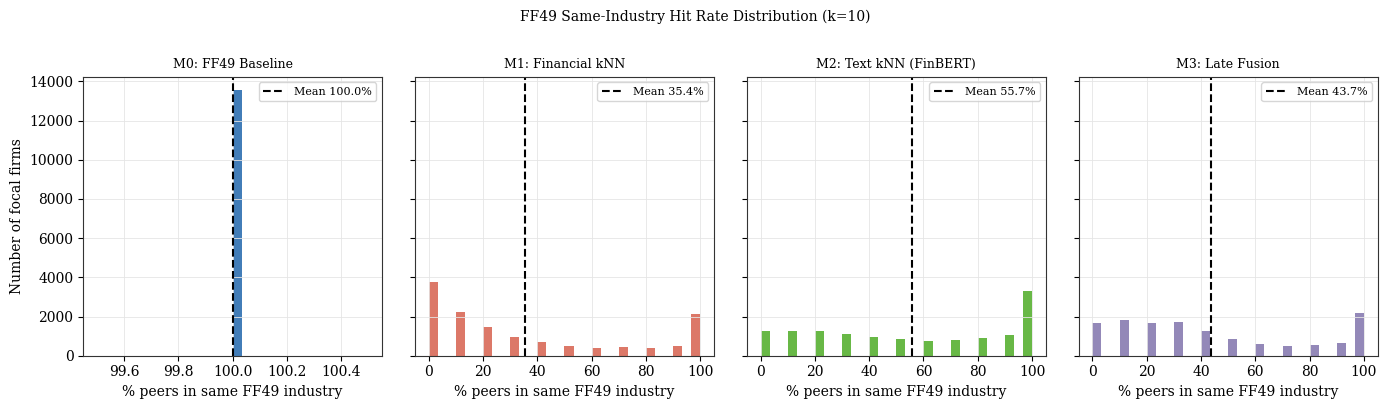

Saved: /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/figures/n10_ff49_hit_rate.pdf


In [29]:
# Figure — hit rate distribution by model
fig, axes = plt.subplots(1, len(MODELS_EVAL), figsize=(14, 4), sharey=True)
colors_list = [C0, C1, C2, C3]

for ax, (model_name, peers_df), color in zip(axes, MODELS_EVAL, colors_list):
    rates = hit_rate_store[(model_name, K_MAIN)] * 100
    ax.hist(rates, bins=30, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(rates.mean(), color='black', linewidth=1.5,
               linestyle='--', label=f'Mean {rates.mean():.1f}%')
    ax.set_title(MODEL_LABELS[model_name], fontsize=9)
    ax.set_xlabel('% peers in same FF49 industry')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Number of focal firms')
plt.suptitle(f'FF49 Same-Industry Hit Rate Distribution (k={K_MAIN})',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'n10_ff49_hit_rate.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'n10_ff49_hit_rate.pdf'}")


## 9. Robustness Checks

### 9.1 December fiscal year-end subsample

December FYE firms account for 81.5% of the panel. This check confirms results
are not driven by non-calendar-year filers.

In [30]:
df_dates = pd.read_parquet(PANEL_CLEAN, columns=['tic','fyear','datadate'])
df_dates['datadate'] = pd.to_datetime(df_dates['datadate'])
df_dates['fiscal_month'] = df_dates['datadate'].dt.month
dec_set = set(zip(
    df_dates[df_dates['fiscal_month']==12]['tic'],
    df_dates[df_dates['fiscal_month']==12]['fyear']
))

print(f"December fiscal year-end firm-years: {len(dec_set):,}")
print(f"\nRobustness — December FYE only (ln_v2s, k=10):")
print(f"  {'Model':<20} {'Full sample':>12} {'Dec only':>12}")
print("  " + "-"*46)

for model_name, peers_df, *_ in MODELS_PLOT:
    r_full = results_df[(results_df['model']==model_name) &
                        (results_df['multiple']=='ln_v2s') &
                        (results_df['k']==K_MAIN)]['mdape'].values[0]
    peers_dec = peers_df[peers_df.apply(
        lambda r: (r['focal_tic'], r['focal_fyear']) in dec_set, axis=1
    )]
    err_dec = compute_mdape(peers_dec, multiples, 'ln_v2s', K_MAIN)
    r_dec   = np.median(err_dec['ape'])
    print(f"  {model_name:<20} {r_full*100:>11.2f}%  {r_dec*100:>11.2f}%")


December fiscal year-end firm-years: 17,015

Robustness — December FYE only (ln_v2s, k=10):
  Model                 Full sample     Dec only
  ----------------------------------------------
  M0_FF49                    54.79%        51.95%
  M1_Financial               43.75%        40.40%
  M2_Text                    51.89%        48.49%
  M3_Fusion                  41.13%        38.50%


### 9.2 Validation vs test year split

Alpha was tuned on 2020–2022 only. Test years 2023–2024 were never consulted
during optimisation. This check confirms the optimal α = 0.3 generalises
out-of-sample.

In [31]:
results_split = []

for period_name, years in [
    ('Validation (2020-2022)', VALIDATION_YEARS),
    ('Test (2023-2024)',       TEST_YEARS),
    ('Full (2020-2024)',       YEARS),
]:
    print(f"  {period_name}:")
    print(f"  {'Model':<20} {'MdAPE':>8} {'n':>7}")
    print(f"  {'-'*38}")
    for model_name, peers_df in MODELS_EVAL:
        peers_period = peers_df[peers_df['focal_fyear'].isin(years)]
        mult_period  = multiples[multiples['fyear'].isin(years)]
        err = compute_mdape(peers_period, mult_period, 'ln_v2s', K_MAIN)
        if len(err) > 0:
            mdape = np.median(err['ape']) * 100
            n     = len(err)
            results_split.append({
                'period': period_name, 'model': model_name,
                'mdape': mdape, 'n': n,
            })
            print(f"  {model_name:<20} {mdape:>7.2f}%  {n:>7,}")
    print()

# H3 check: does M3 improvement over M1 hold on test years?
val_m1  = next(r['mdape'] for r in results_split
               if r['model']=='M1_Financial' and 'Validation' in r['period'])
val_m3  = next(r['mdape'] for r in results_split
               if r['model']=='M3_Fusion' and 'Validation' in r['period'])
test_m1 = next(r['mdape'] for r in results_split
               if r['model']=='M1_Financial' and 'Test' in r['period'])
test_m3 = next(r['mdape'] for r in results_split
               if r['model']=='M3_Fusion' and 'Test' in r['period'])

val_delta  = (val_m1  - val_m3)  / val_m1  * 100
test_delta = (test_m1 - test_m3) / test_m1 * 100

print("M3 improvement over M1 (H3):")
print(f"  Validation years: Δ = +{val_delta:.1f}%")
print(f"  Test years      : Δ = +{test_delta:.1f}%")
print("\n(If test Δ ≈ validation Δ, α generalises well.)")


  Validation (2020-2022):
  Model                   MdAPE       n
  --------------------------------------
  M0_FF49                54.20%    7,943
  M1_Financial           43.23%    7,944
  M2_Text                51.07%    7,944
  M3_Fusion              40.67%    7,944

  Test (2023-2024):
  Model                   MdAPE       n
  --------------------------------------
  M0_FF49                55.64%    5,615
  M1_Financial           44.39%    5,615
  M2_Text                53.48%    5,615
  M3_Fusion              41.89%    5,615

  Full (2020-2024):
  Model                   MdAPE       n
  --------------------------------------
  M0_FF49                54.79%   13,558
  M1_Financial           43.75%   13,559
  M2_Text                51.89%   13,559
  M3_Fusion              41.13%   13,559

M3 improvement over M1 (H3):
  Validation years: Δ = +5.9%
  Test years      : Δ = +5.6%

(If test Δ ≈ validation Δ, α generalises well.)


## 10. Case Studies — Five Roles in the Multimodal Framework

Five focal firms in FY2024, each illustrating a distinct mechanism by which
the four models trade off. Selected from the 2,873-firm evaluation panel via
a peer-coherence filter (M3 top-10 peers must concentrate in $\le 4$ FF49
industries with $\ge 4$ peers in the modal industry containing the focal firm).

- **GS** Goldman Sachs — financial-dominant. M1 identifies the trading-and-
  advisory cluster across the FF49 boundary between Trading and Banking.
- **GIS** General Mills — text-dominant. M2 captures packaged-food brand-
  portfolio differentiation that ratios miss.
- **GILD** Gilead Sciences — consensus-reinforcement. M3 below both M1 and
  M2 individually, demonstrating the fusion mechanism.
- **CSX** CSX Corporation — multimodal-outlier. FF49 Transportation pools
  rail with airlines and trucking; M1 catches the rail-freight signature.
- **TGT** Target Corporation — baseline-survives. M0 already close; M3
  remains within 2pp, showing fusion is robust where industry membership
  already works.

  GILD   FY2024  Consensus-reinforcement     OK
  TGT    FY2024  Baseline-survives           OK
  NVDA   FY2024  Boundary case (scope)       OK
  PFE    FY2024  Post-restructuring drift    OK
  AMZN   FY2024  Boundary case (scope)       OK
  GS     FY2024  Financial-dominant          OK


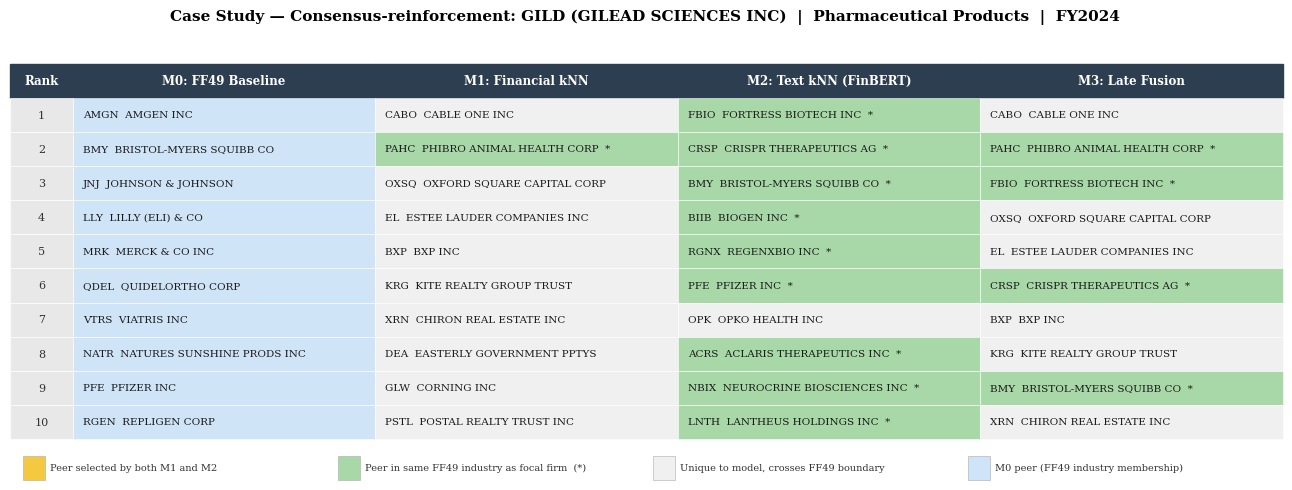

  GILD: Jaccard(M1,M2) = 0.000  |  Shared: none



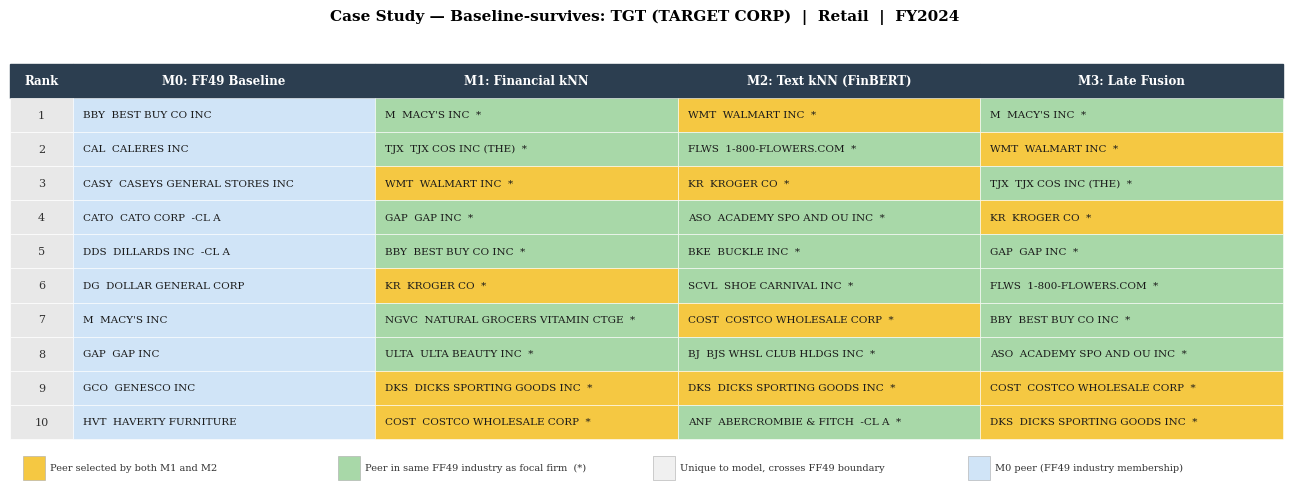

  TGT: Jaccard(M1,M2) = 0.250  |  Shared: COST, DKS, KR, WMT



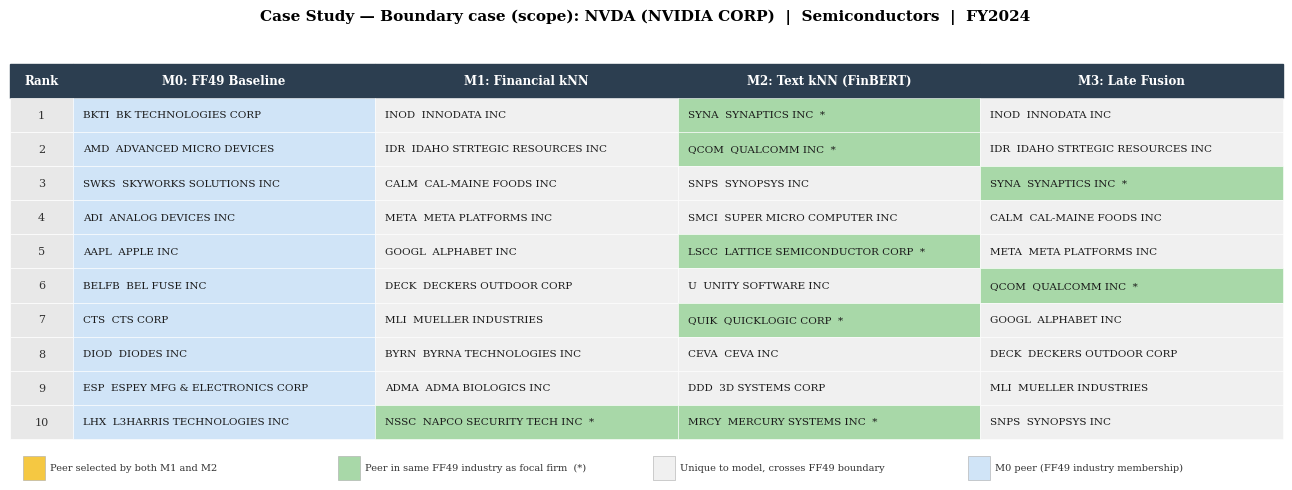

  NVDA: Jaccard(M1,M2) = 0.000  |  Shared: none



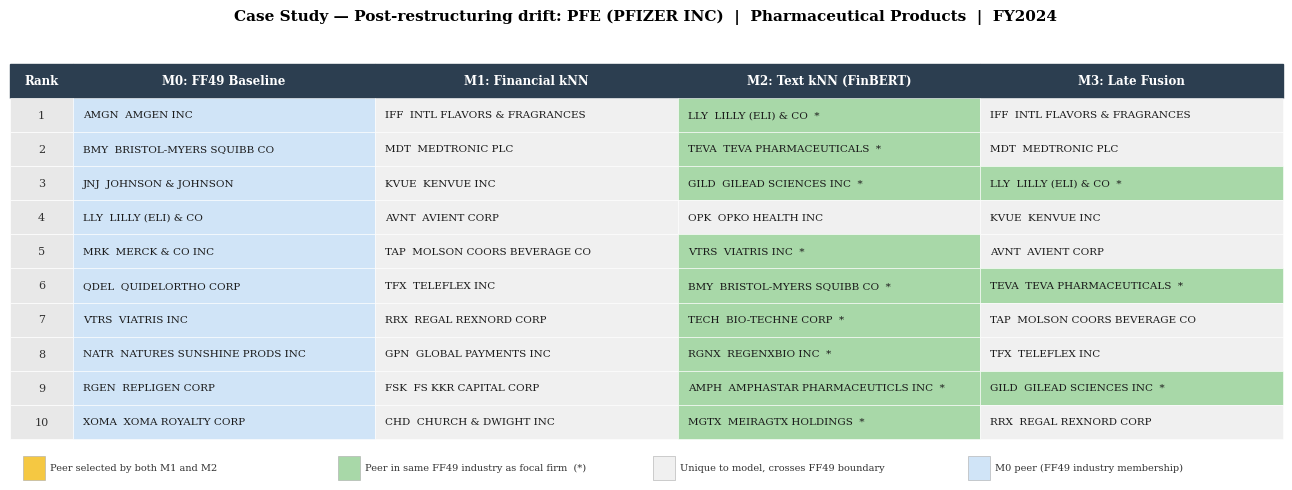

  PFE: Jaccard(M1,M2) = 0.000  |  Shared: none



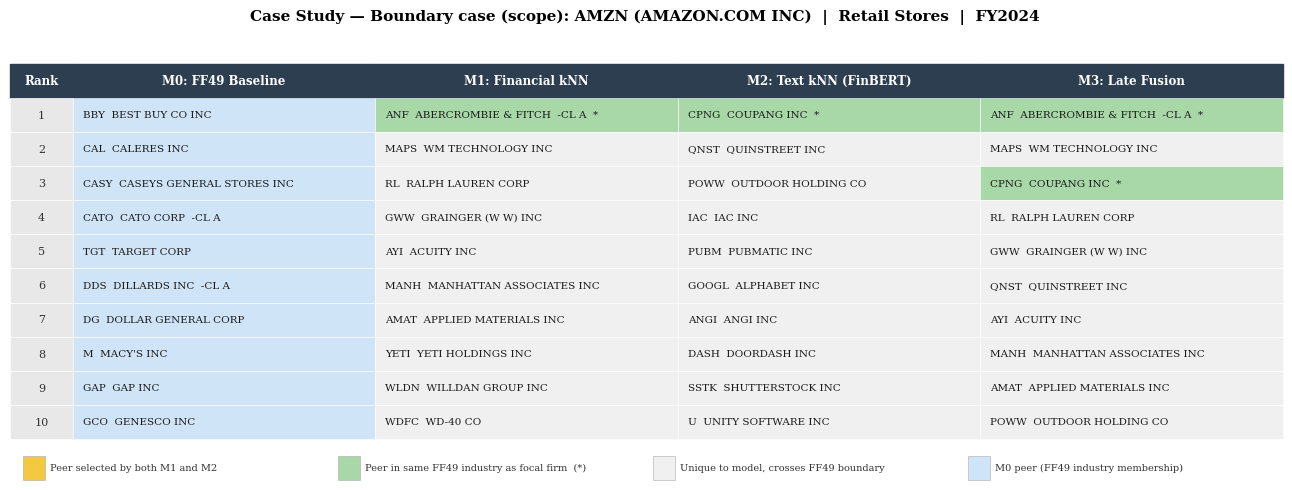

  AMZN: Jaccard(M1,M2) = 0.000  |  Shared: none



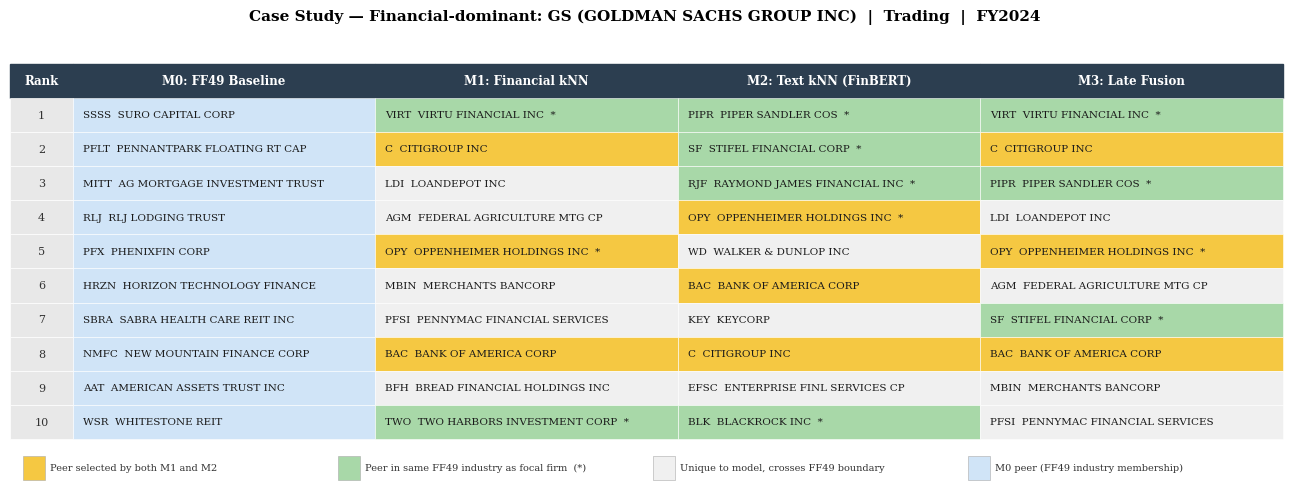

  GS: Jaccard(M1,M2) = 0.176  |  Shared: BAC, C, OPY



In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# Case study setup + peer-list figure (2024, role-balanced shortlist)
# ─────────────────────────────────────────────────────────────────────────────

# Lookups (built once, reused throughout §10)
name_lookup = (pd.read_parquet(PANEL_CLEAN, columns=['tic', 'conm'])
               .drop_duplicates('tic').set_index('tic')['conm'].to_dict())
industry_lookup = (df_panel[['tic', 'fyear', 'ff49_num', 'industry']]
                   .set_index(['tic', 'fyear']))

def get_name(tic, maxlen=28):
    n = name_lookup.get(tic, tic)
    return n[:maxlen]

def get_ff49(tic, yr):
    try:    return industry_lookup.loc[(tic, yr), 'ff49_num']
    except KeyError: return None

FOCAL_FIRMS = [
    ('GILD', 2024, 'Pharmaceutical Products',    'Consensus-reinforcement'),
    ('TGT',  2024, 'Retail',                  'Baseline-survives'),
    ('NVDA', 2024, 'Semiconductors',          'Boundary case (scope)'),
    ('PFE',  2024, 'Pharmaceutical Products', 'Post-restructuring drift'),
    ('AMZN', 2024, 'Retail Stores',           'Boundary case (scope)'),
    ('GS',   2024, 'Trading',                    'Financial-dominant'),
]

ALL_PEERS = {'M0_FF49': peers_m0, 'M1_Financial': peers_m1,
             'M2_Text': peers_m2, 'M3_Fusion':    peers_m3}

# Sanity check
eval_focal = set(zip(peers_m3['focal_tic'], peers_m3['focal_fyear']))
for tic, yr, _, role in FOCAL_FIRMS:
    status = 'OK' if (tic, yr) in eval_focal else 'MISSING'
    print(f"  {tic:<6} FY{yr}  {role:<26}  {status}")

# ── Peer-list figure ────────────────────────────────────────────────────────
K_DISPLAY = 10
COLORS    = {'agree':   '#f5c842', 'ff49':    '#a8d8a8',
             'default': '#f0f0f0', 'm0':      '#d0e4f7',
             'header':  '#2c3e50'}

def peer_color(peer_tic, focal_ff49, m1_set, m2_set, model, yr):
    if model == 'M0_FF49': return COLORS['m0']
    if peer_tic in m1_set and peer_tic in m2_set: return COLORS['agree']
    if get_ff49(peer_tic, yr) == focal_ff49:      return COLORS['ff49']
    return COLORS['default']

def get_top_peers(tic, yr, peers_df, k=K_DISPLAY):
    return (peers_df[(peers_df['focal_tic'] == tic) &
                     (peers_df['focal_fyear'] == yr) &
                     (peers_df['rank'] <= k)]
            .sort_values('rank')['peer_tic'].tolist())

for focal_tic, yr, industry, role in FOCAL_FIRMS:
    focal_ff49 = get_ff49(focal_tic, yr)
    peer_lists = {m: get_top_peers(focal_tic, yr, df) for m, df in ALL_PEERS.items()}
    m1_set, m2_set = set(peer_lists['M1_Financial']), set(peer_lists['M2_Text'])

    fig, ax = plt.subplots(figsize=(13, 6.8))
    ax.axis('off')

    col_labels = ['Rank', 'M0: FF49 Baseline', 'M1: Financial kNN',
                  'M2: Text kNN (FinBERT)', 'M3: Late Fusion']
    col_widths  = [0.05, 0.24, 0.24, 0.24, 0.24]
    x_pos       = [sum(col_widths[:i]) for i in range(len(col_widths))]
    row_h, y0   = 0.14, 0.85

    # Header row
    for label, xp, w in zip(col_labels, x_pos, col_widths):
        ax.add_patch(plt.Rectangle((xp, y0), w, row_h, transform=ax.transAxes,
                                    color=COLORS['header'], clip_on=False))
        ax.text(xp + w/2, y0 + row_h/2, label, transform=ax.transAxes,
                ha='center', va='center', fontsize=8.5,
                color='white', fontweight='bold')

    # Peer rows
    models = list(ALL_PEERS.keys())
    for r_idx in range(K_DISPLAY):
        y = y0 - (r_idx + 1) * row_h
        # Rank cell
        ax.add_patch(plt.Rectangle((x_pos[0], y), col_widths[0], row_h,
                                    transform=ax.transAxes, color='#e8e8e8',
                                    clip_on=False, lw=0.5, ec='white'))
        ax.text(x_pos[0] + col_widths[0]/2, y + row_h/2, str(r_idx + 1),
                transform=ax.transAxes, ha='center', va='center',
                fontsize=8, color='#333333')
        # Model cells
        for c_idx, model in enumerate(models):
            xp, w = x_pos[c_idx + 1], col_widths[c_idx + 1]
            peers = peer_lists[model]
            if r_idx < len(peers):
                pt = peers[r_idx]
                color = peer_color(pt, focal_ff49, m1_set, m2_set, model, yr)
                star  = '  *' if (get_ff49(pt, yr) == focal_ff49 and
                                   model != 'M0_FF49') else ''
                label = f"{pt}  {get_name(pt)}{star}"
            else:
                color, label = '#ffffff', '—'
            ax.add_patch(plt.Rectangle((xp, y), w, row_h, transform=ax.transAxes,
                                        color=color, clip_on=False,
                                        lw=0.4, ec='white'))
            ax.text(xp + 0.008, y + row_h/2, label, transform=ax.transAxes,
                    ha='left', va='center', fontsize=7.5, color='#1a1a1a')

    # Legend
    legend_y = y0 - (K_DISPLAY + 1.2) * row_h
    legend_items = [
        (COLORS['agree'],   'Peer selected by both M1 and M2'),
        (COLORS['ff49'],    'Peer in same FF49 industry as focal firm  (*)'),
        (COLORS['default'], 'Unique to model, crosses FF49 boundary'),
        (COLORS['m0'],      'M0 peer (FF49 industry membership)'),
    ]
    for i, (color, lbl) in enumerate(legend_items):
        xp = 0.01 + i * 0.25
        ax.add_patch(plt.Rectangle((xp, legend_y), 0.018, row_h * 0.7,
                                    transform=ax.transAxes, color=color,
                                    clip_on=False, lw=0.4, ec='#aaaaaa'))
        ax.text(xp + 0.022, legend_y + row_h * 0.35, lbl,
                transform=ax.transAxes, ha='left', va='center',
                fontsize=7, color='#333333')

    fig.suptitle(f"Case Study — {role}: {focal_tic} ({get_name(focal_tic)})  |  "
                 f"{industry}  |  FY{yr}",
                 fontsize=11, fontweight='bold', y=1.01)
    fig.tight_layout()
    plt.savefig(FIGURES / f"n10_case_{focal_tic.lower()}.pdf",
                dpi=FIGURE_DPI, bbox_inches='tight')
    plt.show()

    # Jaccard summary
    inter, union = m1_set & m2_set, m1_set | m2_set
    j = len(inter) / len(union) if union else 0
    shared = ', '.join(sorted(inter)) if inter else 'none'
    print(f"  {focal_tic}: Jaccard(M1,M2) = {j:.3f}  |  Shared: {shared}\n")

### 10.1 Implied valuations and APE by model

For each case-study firm, compute the peer-median-implied EV/Sales multiple
under each model and the resulting absolute percentage error relative to the
actual multiple.

  IMPLIED VALUATIONS — Multiple and $ EV  |  k=10  |  FY2024

  GILD  (Consensus-reinforcement)  —  Pharmaceutical Products
  Sales = $28,754M  |  Actual EV = $130,847M  |  Actual EV/Sales = 4.55x
  Model          Implied EV/S     APE   Implied EV $M     EV gap $M  EV gap %  Mean cosine
  ---------------------------------------------------------------------------------------------
  M0_FF49              6.36x   39.7%        182,809       +51,962     +39.7%       1.0000
  M1_Financial         6.92x   52.1%        198,998       +68,151     +52.1%       0.7895
  M2_Text              3.34x   26.5%         96,133       -34,714     -26.5%       0.9815
  M3_Fusion            4.59x    0.8%        131,890        +1,043      +0.8%       0.8577

  TGT  (Baseline-survives)  —  Retail
  Sales = $106,566M  |  Actual EV = $77,940M  |  Actual EV/Sales = 0.73x
  Model          Implied EV/S     APE   Implied EV $M     EV gap $M  EV gap %  Mean cosine
  ---------------------------------------------------

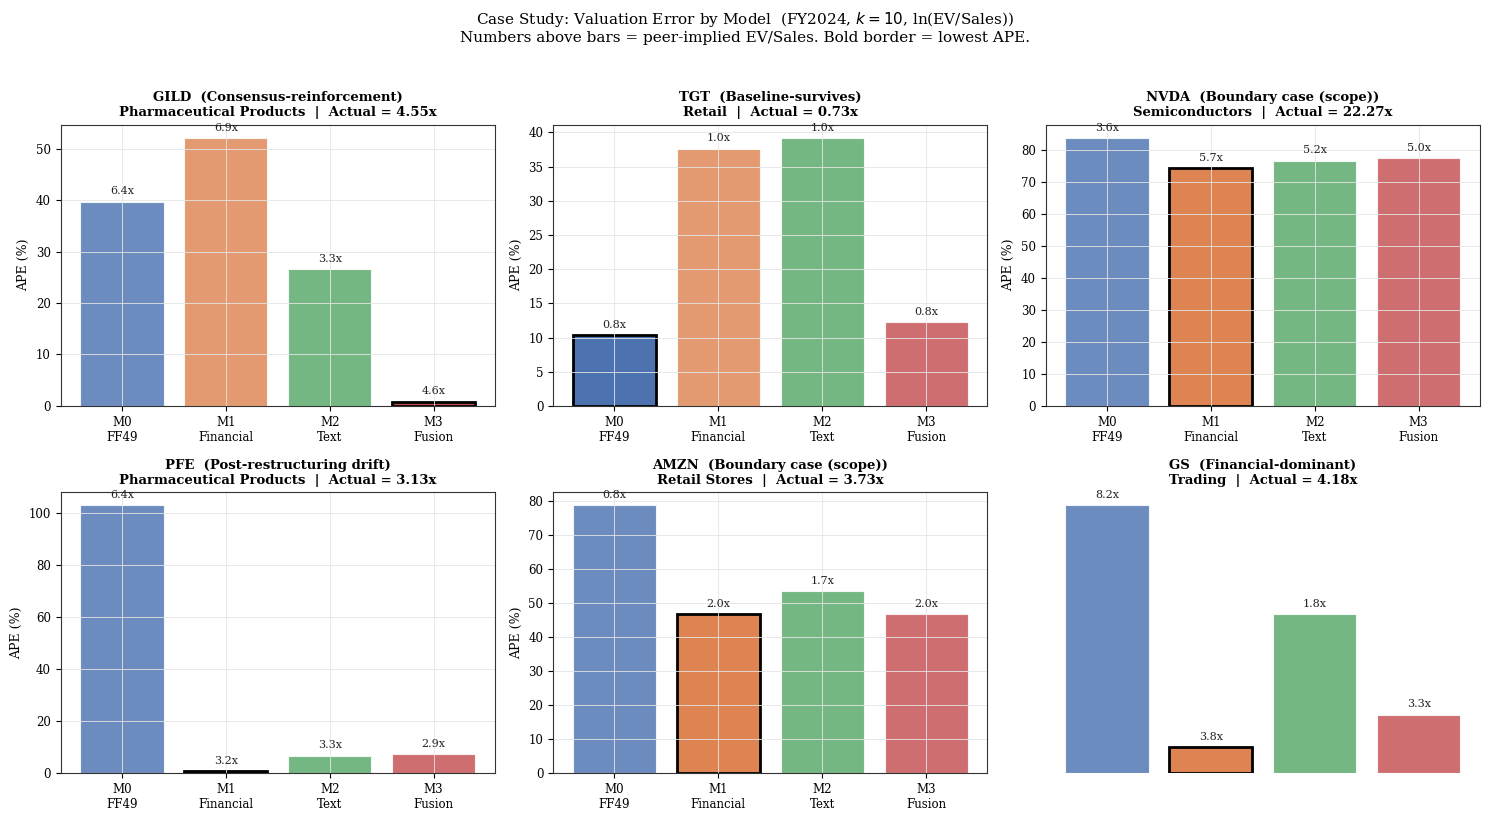

Saved: /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/figures/n10_case_study_ape.pdf


In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# Implied valuations + APE bar chart — now with $ EV columns
# ─────────────────────────────────────────────────────────────────────────────

K_VAL = 10

# Pull sales and EV directly from the parquet (df_panel may not have these columns)
case_years = [yr for _, yr, _, _ in FOCAL_FIRMS]
focal_financials = (pd.read_parquet(PANEL_CLEAN, columns=['tic', 'fyear', 'sale', 'ev'])
                    .pipe(lambda d: d[d['fyear'].isin(case_years)])
                    .rename(columns={'tic': 'focal_tic', 'fyear': 'focal_fyear'}))

with open(ALPHA_OPTIMAL) as f:
    best_alpha = json.load(f)['best_alpha']  # 0.3

def implied_valuation(focal_tic, yr, peers_df, mult_df,
                       financials_df, col='ln_v2s', k=K_VAL, model_name=None):
    peers_k = (peers_df[(peers_df['focal_tic'] == focal_tic) &
                         (peers_df['focal_fyear'] == yr) &
                         (peers_df['rank'] <= k)]
               .merge(mult_df.loc[mult_df['fyear'] == yr,
                                   ['tic', col]].rename(
                          columns={'tic': 'peer_tic', col: 'peer_mult'}),
                      on='peer_tic', how='left'))
    implied_ln = peers_k['peer_mult'].median()
    actual_row = mult_df[(mult_df['fyear'] == yr) &
                          (mult_df['tic']   == focal_tic)][col]
    fin_row = financials_df[(financials_df['focal_tic']   == focal_tic) &
                              (financials_df['focal_fyear'] == yr)]
    if actual_row.empty or pd.isna(implied_ln) or fin_row.empty:
        return None

    # ── cosine: for M3 blend M1+M2 cosines; others use stored score ──────
    if model_name == 'M3_Fusion':
        m1_scores = (peers_m1[(peers_m1['focal_tic'] == focal_tic) &
                               (peers_m1['focal_fyear'] == yr) &
                               (peers_m1['peer_tic'].isin(peers_k['peer_tic']))]
                     .set_index('peer_tic')['similarity_score'])
        m2_scores = (peers_m2[(peers_m2['focal_tic'] == focal_tic) &
                               (peers_m2['focal_fyear'] == yr) &
                               (peers_m2['peer_tic'].isin(peers_k['peer_tic']))]
                     .set_index('peer_tic')['similarity_score'])
        mean_cosine = ((1 - best_alpha) * m1_scores.mean() +
                       best_alpha       * m2_scores.mean())
    else:
        mean_cosine = float(peers_k['similarity_score'].mean())

    actual_mult  = float(np.exp(actual_row.values[0]))
    implied_mult = float(np.exp(implied_ln))
    sale         = float(fin_row['sale'].iloc[0])
    actual_ev    = float(fin_row['ev'].iloc[0])
    implied_ev   = implied_mult * sale

    return {
        'actual_mult':   actual_mult,
        'implied_mult':  implied_mult,
        'sale_$M':       sale,
        'actual_ev_$M':  actual_ev,
        'implied_ev_$M': implied_ev,
        'ev_gap_$M':     implied_ev - actual_ev,
        'ev_gap_pct':    (implied_ev - actual_ev) / abs(actual_ev) * 100,
        'ape':           abs(actual_mult - implied_mult) / abs(actual_mult) * 100,
        'n_peers':       int(peers_k['peer_mult'].notna().sum()),
        'mean_cosine':   float(mean_cosine),
    }

# Rebuild records passing model_name through
records = []
for focal_tic, yr, industry, role in FOCAL_FIRMS:
    for model_name, peers_df in ALL_PEERS.items():
        res = implied_valuation(focal_tic, yr, peers_df, multiples,
                                 focal_financials, model_name=model_name)
        if res is None: continue
        records.append({'focal_tic': focal_tic, 'industry': industry,
                        'role': role, 'model': model_name, **res})

val_df = pd.DataFrame(records)

# ── Print formatted summary per firm (now with $ EV columns) ───────────────
print("=" * 105)
print(f"  IMPLIED VALUATIONS — Multiple and $ EV  |  k={K_VAL}  |  FY2024")
print("=" * 105)
for focal_tic, yr, industry, role in FOCAL_FIRMS:
    sub = val_df[val_df['focal_tic'] == focal_tic]
    if sub.empty: continue
    actual_mult = sub['actual_mult'].iloc[0]
    actual_ev   = sub['actual_ev_$M'].iloc[0]
    sale        = sub['sale_$M'].iloc[0]
    print(f"\n  {focal_tic}  ({role})  —  {industry}")
    print(f"  Sales = ${sale:,.0f}M  |  Actual EV = ${actual_ev:,.0f}M  |  "
          f"Actual EV/Sales = {actual_mult:.2f}x")
    print(f"  {'Model':<14} {'Implied EV/S':>12} {'APE':>7}  "
          f"{'Implied EV $M':>14} {'EV gap $M':>13} {'EV gap %':>9} {'Mean cosine':>12}")  # ← +header
    print(f"  {'-' * 93}")
    for _, r in sub.iterrows():
        print(f"  {r['model']:<14} "
              f"{r['implied_mult']:>10.2f}x  "
              f"{r['ape']:>5.1f}%  "
              f"{r['implied_ev_$M']:>13,.0f}  "
              f"{r['ev_gap_$M']:>+12,.0f}  "
              f"{r['ev_gap_pct']:>+8.1f}%  "
              f"{r['mean_cosine']:>11.4f}")  # ← added

val_df.to_csv(DATA_RESULTS / 'case_study_valuations.csv', index=False)
print(f"\nSaved: {DATA_RESULTS / 'case_study_valuations.csv'}")

# ── Side-by-side compact $ EV summary table (one row per firm) ──────────────
print(f"\n{'=' * 105}")
print(f"  COMPACT $ EV TABLE  —  Implied EV by Model ($ millions)")
print(f"{'=' * 105}")
print(f"  {'Tic':<6} {'Role':<26} {'Actual EV':>12}  "
      f"{'M0 EV':>11} {'M1 EV':>11} {'M2 EV':>11} {'M3 EV':>11}")
print(f"  {'-' * 100}")
for focal_tic, yr, industry, role in FOCAL_FIRMS:
    sub = val_df[val_df['focal_tic'] == focal_tic]
    if sub.empty: continue
    actual_ev = sub['actual_ev_$M'].iloc[0]
    evs = {m: sub.loc[sub['model'] == m, 'implied_ev_$M'].values[0]
            if not sub[sub['model'] == m].empty else np.nan
            for m in ['M0_FF49', 'M1_Financial', 'M2_Text', 'M3_Fusion']}
    print(f"  {focal_tic:<6} {role:<26} {actual_ev:>11,.0f}  "
          f"{evs['M0_FF49']:>10,.0f}  {evs['M1_Financial']:>10,.0f}  "
          f"{evs['M2_Text']:>10,.0f}  {evs['M3_Fusion']:>10,.0f}")

# ── APE bar chart (unchanged from previous version) ────────────────────────
MODEL_ORDER = ['M0_FF49', 'M1_Financial', 'M2_Text', 'M3_Fusion']
MODEL_SHORT = {'M0_FF49':      'M0\nFF49',
               'M1_Financial': 'M1\nFinancial',
               'M2_Text':      'M2\nText',
               'M3_Fusion':    'M3\nFusion'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
axes[5].axis('off')

for ax, (focal_tic, yr, industry, role) in zip(axes, FOCAL_FIRMS):
    sub = val_df[val_df['focal_tic'] == focal_tic]
    if sub.empty:
        ax.axis('off'); continue
    actual = sub['actual_mult'].iloc[0]

    apes = [sub.loc[sub['model'] == m, 'ape'].values[0]
             if not sub[sub['model'] == m].empty else np.nan
             for m in MODEL_ORDER]
    implieds = [sub.loc[sub['model'] == m, 'implied_mult'].values[0]
                 if not sub[sub['model'] == m].empty else np.nan
                 for m in MODEL_ORDER]
    bar_cols = [MODEL_COLORS[m] for m in MODEL_ORDER]

    bars = ax.bar(range(len(MODEL_ORDER)), apes,
                  color=bar_cols, alpha=0.82, edgecolor='white', linewidth=0.8)

    valid = [(i, a) for i, a in enumerate(apes) if not np.isnan(a)]
    if valid:
        best = min(valid, key=lambda x: x[1])[0]
        bars[best].set_edgecolor('black')
        bars[best].set_linewidth(2.0)
        bars[best].set_alpha(1.0)

    for bar, imp in zip(bars, implieds):
        if not np.isnan(imp):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(apes) * 0.02,
                    f'{imp:.1f}x', ha='center', va='bottom',
                    fontsize=8, color='#222222')

    ax.axhline(0, color='#999999', linewidth=0.5)
    ax.set_title(f'{focal_tic}  ({role})\n{industry}  |  '
                 f'Actual = {actual:.2f}x',
                 fontsize=9.5, fontweight='bold')
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels([MODEL_SHORT[m] for m in MODEL_ORDER], fontsize=8.5)
    ax.set_ylabel('APE (%)', fontsize=9)
    ax.tick_params(labelsize=8.5)

fig.suptitle('Case Study: Valuation Error by Model  '
             r'(FY2024, $k=10$, ln(EV/Sales))'
             '\nNumbers above bars = peer-implied EV/Sales. Bold border = lowest APE.',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'n10_case_study_ape.pdf',
            dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'n10_case_study_ape.pdf'}")

In [34]:
import pandas as pd
df = pd.read_csv("data/results/h4_final/phase_a_main_results.csv")
print(df.columns.tolist())
print(df.head(10))

['Stratum', 'n', 'M0_MdAPE', 'M0_CI', 'M1_MdAPE', 'M1_CI', 'M2_MdAPE', 'M2_CI', 'M3_MdAPE', 'M3_CI', 'Δ M1-M0', 'p_M1_M0', 'Δ M2-M0', 'p_M2_M0', 'Δ M3-M1', 'p_M3_M1', 'Δ M3-M0', 'p_M3_M0']
      Stratum     n  M0_MdAPE           M0_CI  M1_MdAPE           M1_CI  \
0  R&D-Active  5685     52.58  [51.03, 54.44]     40.07  [38.89, 41.35]   
1    R&D-Zero  7873     56.97  [55.05, 59.29]     47.33  [45.70, 49.20]   

   M2_MdAPE           M2_CI  M3_MdAPE           M3_CI  Δ M1-M0  p_M1_M0  \
0     49.39  [47.75, 51.16]     38.47  [37.31, 39.60]    23.79      0.0   
1     54.90  [52.83, 56.59]     43.98  [42.37, 45.24]    16.93      0.0   

   Δ M2-M0  p_M2_M0  Δ M3-M1  p_M3_M1  Δ M3-M0  p_M3_M0  
0     6.07      0.0     4.01   0.0008    26.84      0.0  
1     3.63      0.0     7.07   0.0000    22.81      0.0  


In [35]:
import pandas as pd
from config import SUMMARIES_FILES

df = pd.read_csv(SUMMARIES_FILES[2024])
print(df[df["tic"] == "NVDA"]["business_description"].iloc[0])

NVIDIA is a pioneering accelerated computing company that has evolved into a data center-scale AI infrastructure provider, fundamentally reshaping diverse industries. Its core business model revolves around designing and selling high-performance computing platforms, primarily centered on Graphics Processing Units (GPUs), Data Processing Units (DPUs), and Central Processing Units (CPUs), integrated with a comprehensive software stack. Revenue is generated through the sale of these hardware components, associated software licenses (e.g., NVIDIA AI Enterprise, vGPU software), and development services across four key markets: Data Center, Gaming, Professional Visualization, and Automotive.

The firm's primary products and services include a unified, programmable architecture built on NVIDIA GPUs, CPUs, and DPUs. Key intellectual property and offerings include the foundational NVIDIA CUDA development platform, hundreds of domain-specific software libraries, frameworks, algorithms, SDKs, and

Testing Zone

In [36]:
# ── Cell — Build panel_eval, APE frame, helpers ───────────────────────────────
panel_full = pd.read_parquet(PANEL_CLEAN)
multiples  = pd.read_parquet(MULTIPLES)
emb_df     = pd.read_parquet(EMBEDDINGS)

m0, m1, m2, m3 = peers_m0, peers_m1, peers_m2, peers_m3

MULT_COLS = ['ln_v2s', 'ln_v2a', 'ln_m2b']

# ── Build evaluation sample ───────────────────────────────────────────────────
eval_set   = emb_df[['tic', 'fyear']].drop_duplicates()
panel_eval = panel_full.merge(eval_set, on=['tic', 'fyear'], how='inner')

# Merge only the multiple columns — avoid column collisions
panel_eval = panel_eval.merge(
    multiples[['tic', 'fyear'] + MULT_COLS],
    on=['tic', 'fyear'], how='left'
)

print(f'panel_eval : {len(panel_eval):,} rows')
print(f'panel_eval columns sample: {panel_eval.columns.tolist()[:15]}')

# ── APE computation ───────────────────────────────────────────────────────────
# Use multiples directly — already has tic/fyear + ln_* columns
mult_slim = multiples[['tic', 'fyear'] + MULT_COLS].copy()

def compute_ape(peers_df, multiples_df, multiple_col, k=10):
    top = (peers_df[peers_df['rank'] <= k]
           .copy()
           .rename(columns={'peer_tic': 'tic', 'focal_fyear': 'fyear'}))
    peer_mult = top.merge(
        multiples_df[['tic', 'fyear', multiple_col]],
        on=['tic', 'fyear'], how='inner')
    if peer_mult.empty:
        return pd.DataFrame(columns=['focal_tic', 'focal_fyear',
                                     f'ape_{multiple_col}'])
    peer_med = (peer_mult
                .groupby(['focal_tic', 'fyear'])[multiple_col]
                .median()
                .reset_index()
                .rename(columns={'fyear':        'focal_fyear',
                                 multiple_col:   'peer_med'}))
    focal_mult = (multiples_df[['tic', 'fyear', multiple_col]]
                  .rename(columns={'tic':   'focal_tic',
                                   'fyear': 'focal_fyear'}))
    result = peer_med.merge(focal_mult,
                            on=['focal_tic', 'focal_fyear'], how='inner')
    result['ape'] = ((result[multiple_col] - result['peer_med']).abs()
                     / result[multiple_col].abs())
    return (result[['focal_tic', 'focal_fyear', 'ape']]
            .rename(columns={'ape': f'ape_{multiple_col}'}))

peer_dfs = {'m0': m0, 'm1': m1, 'm2': m2, 'm3': m3}
ape_all  = None
for mult_col in MULT_COLS:
    df_mult = None
    for mod, peers in peer_dfs.items():
        a = compute_ape(peers, mult_slim, mult_col).rename(
            columns={f'ape_{mult_col}': f'ape_{mod}_{mult_col}'})
        df_mult = (a if df_mult is None
                   else df_mult.merge(a, on=['focal_tic', 'focal_fyear'],
                                      how='outer'))
    ape_all = (df_mult if ape_all is None
               else ape_all.merge(df_mult, on=['focal_tic', 'focal_fyear'],
                                  how='outer'))

# ── Attach metadata from panel_eval ──────────────────────────────────────────
meta_cols = ['tic', 'fyear', 'conm', 'industry', 'market_cap',
             'ff49_num', 'ln_v2s']
meta_cols += ['xrd'] if 'xrd' in panel_eval.columns else []

panel_meta = (panel_eval[[c for c in meta_cols if c in panel_eval.columns]]
              .drop_duplicates(subset=['tic', 'fyear'])
              .rename(columns={'tic': 'focal_tic', 'fyear': 'focal_fyear'}))

ape_all = ape_all.merge(panel_meta, on=['focal_tic', 'focal_fyear'], how='left')

# ── Helper functions ──────────────────────────────────────────────────────────
def get_name(tic):
    row = panel_eval[panel_eval['tic'] == tic]['conm']
    return row.iloc[0] if len(row) else tic

def get_ff49(tic, yr):
    row = panel_eval[(panel_eval['tic'] == tic) &
                     (panel_eval['fyear'] == yr)]['ff49_num']
    return row.iloc[0] if len(row) else None

def get_top_peers(tic, yr, peers_df, k=10):
    return (peers_df[(peers_df['focal_tic'] == tic) &
                     (peers_df['focal_fyear'] == yr) &
                     (peers_df['rank'] <= k)]
            .sort_values('rank')['peer_tic']
            .tolist())

ALL_PEERS = {
    'M0_FF49':      m0,
    'M1_Financial': m1,
    'M2_Text':      m2,
    'M3_Fusion':    m3,
}

print(f'ape_all    : {len(ape_all):,} rows')
print(f'ape_all columns: {ape_all.columns.tolist()}')
print('Ready.')

panel_eval : 13,559 rows
panel_eval columns sample: ['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'sic', 'curncd', 'fyear', 'act', 'ap', 'at']
ape_all    : 13,559 rows
ape_all columns: ['focal_tic', 'focal_fyear', 'ape_m0_ln_v2s', 'ape_m1_ln_v2s', 'ape_m2_ln_v2s', 'ape_m3_ln_v2s', 'ape_m0_ln_v2a', 'ape_m1_ln_v2a', 'ape_m2_ln_v2a', 'ape_m3_ln_v2a', 'ape_m0_ln_m2b', 'ape_m1_ln_m2b', 'ape_m2_ln_m2b', 'ape_m3_ln_m2b', 'conm', 'industry', 'market_cap', 'ff49_num', 'ln_v2s', 'xrd']
Ready.


In [37]:
import pandas as pd
from config import SUMMARIES_FILES

df = pd.read_csv(SUMMARIES_FILES[2024])

match = df[df["tic"] == "PFE"]
if match.empty:
    print("PFE not found in 2024 summaries")
else:
    print(match["business_description"].iloc[0])

Pfizer Inc. operates as a global, research-based biopharmaceutical company, generating revenue primarily through the discovery, development, manufacture, marketing, sale, and distribution of a diverse portfolio of biopharmaceutical products worldwide. The core business model centers on applying scientific innovation to create therapies that extend and improve patient lives, maximizing product value, and ensuring patient access through strategic pricing and contracting with payors. Growth is driven by advancing its internal product pipeline, optimizing existing brands, and engaging in strategic business development activities, including acquisitions and in-licensing agreements, alongside scaling artificial intelligence across its operations for enhanced productivity and innovation.

Commercial operations are primarily managed through the Biopharma segment, which encompasses global divisions for U.S. and International markets, and a specialized Global Hospital and Biosimilars organizatio

In [38]:
# ── Cell — Find top WMT replacement candidates ────────────────────────────
EXCLUDE   = {'AMZN', 'MSFT', 'PFE', 'WMT', 'XOM'}
CASE_YEAR = 2022

def jaccard_for_firm(focal_tic, yr, peers_m1, peers_m2, k=10):
    def get_set(df):
        sub = df[(df['focal_tic'] == focal_tic) &
                 (df['focal_fyear'] == yr) &
                 (df['rank'] <= k)]
        return set(sub['peer_tic'].tolist())
    s1, s2 = get_set(peers_m1), get_set(peers_m2)
    union  = s1 | s2
    return len(s1 & s2) / len(union) if union else 0.0

ape_2022 = ape_all[ape_all['focal_fyear'] == CASE_YEAR].copy()
ape_2022['jaccard'] = ape_2022['focal_tic'].apply(
    lambda t: jaccard_for_firm(t, CASE_YEAR, m1, m2))

cands = ape_2022[
    (~ape_2022['focal_tic'].isin(EXCLUDE))                          &
    (ape_2022['ape_m3_ln_v2s'] < ape_2022['ape_m0_ln_v2s'])        &
    (ape_2022['ape_m1_ln_v2s'] < ape_2022['ape_m0_ln_v2s'])        &
    (ape_2022['ape_m2_ln_v2s'] < ape_2022['ape_m0_ln_v2s'])        &
    (ape_2022['jaccard']       >= 0.10)                             &
    (ape_2022['ape_m3_ln_v2s'] <  0.40)                            &
    (ape_2022['ape_m0_ln_v2s'] >  0.15)                            &
    (ape_2022['ape_m0_ln_v2s'] <  1.50)                            &
    (ape_2022['ln_v2s'].between(-1, 3))                             &
    (ape_2022['ape_m2_ln_v2s'].notna())
].copy()

cands['m3_gain_vs_m0'] = cands['ape_m0_ln_v2s'] - cands['ape_m3_ln_v2s']
cands['m3_gain_vs_m1'] = cands['ape_m1_ln_v2s'] - cands['ape_m3_ln_v2s']
cands['score'] = (
    cands['m3_gain_vs_m0'] * 0.5 +
    cands['m3_gain_vs_m1'] * 0.3 +
    cands['jaccard']        * 0.2
)

top10 = (cands
         .sort_values('score', ascending=False)
         .head(65)
         [['focal_tic', 'conm', 'industry', 'market_cap', 'ln_v2s',
           'jaccard', 'ape_m0_ln_v2s', 'ape_m1_ln_v2s',
           'ape_m2_ln_v2s', 'ape_m3_ln_v2s', 'm3_gain_vs_m0']]
         .rename(columns={
             'focal_tic':     'Ticker',
             'conm':          'Company',
             'industry':      'FF49 Industry',
             'market_cap':    'Mkt Cap $M',
             'ln_v2s':        'ln(EV/S)',
             'jaccard':       'Jaccard',
             'ape_m0_ln_v2s': 'APE M0',
             'ape_m1_ln_v2s': 'APE M1',
             'ape_m2_ln_v2s': 'APE M2',
             'ape_m3_ln_v2s': 'APE M3',
             'm3_gain_vs_m0': 'M3 gain vs M0',
         }))

for col in ['APE M0', 'APE M1', 'APE M2', 'APE M3', 'M3 gain vs M0']:
    top10[col] = top10[col].map(
        lambda x: f'{x*100:.1f}%' if pd.notna(x) else '—')
top10['Jaccard']    = top10['Jaccard'].map(lambda x: f'{x:.3f}')
top10['Mkt Cap $M'] = top10['Mkt Cap $M'].map(
    lambda x: f'{x:,.0f}' if pd.notna(x) else '—')
top10['ln(EV/S)']   = top10['ln(EV/S)'].map(
    lambda x: f'{x:.2f}' if pd.notna(x) else '—')

print('=' * 140)
print('TOP 10 REPLACEMENT CANDIDATES FOR WMT  |  FY2022')
print('All three models beat M0 | Jaccard >= 0.10 | M3 APE < 40% | M0 APE > 15%')
print('=' * 140)
print(top10.to_string(index=False))
print(f'\nTotal candidates passing filters: {len(cands):,}')

TOP 10 REPLACEMENT CANDIDATES FOR WMT  |  FY2022
All three models beat M0 | Jaccard >= 0.10 | M3 APE < 40% | M0 APE > 15%
Ticker                      Company             FF49 Industry Mkt Cap $M ln(EV/S) Jaccard APE M0 APE M1 APE M2 APE M3 M3 gain vs M0
   OKE                    ONEOK INC                 Utilities     29,378     0.65   0.111 112.2%  24.7%  32.6%   2.7%        109.4%
    PK        PARK HOTELS & RESORTS                   Trading      2,642     0.95   0.176 123.7%  16.7%  20.6%  12.5%        111.2%
   XHR   XENIA HOTELS & RESORTS INC                   Trading      1,483     0.94   0.176 125.4%  13.3%  22.9%  14.9%        110.6%
   RLJ            RLJ LODGING TRUST                   Trading      1,716     1.08   0.250  98.1%   3.5%   4.3%   0.5%         97.6%
   DRH   DIAMONDROCK HOSPITALITY CO                   Trading      1,715     1.07   0.176  99.8%   4.2%  38.8%   4.2%         95.5%
   CCL   CARNIVAL CORPORATION & PLC            Transportation     12,502     1.25   0.

In [39]:
# ── Cell — Firm-level peer detail for chosen candidate ────────────────────────
# Set this to whichever ticker you pick from the top 10 above
CHOSEN_TIC = 'AMZN' # Changed from a set to a single string

# Fetch the industry for the chosen focal_tic and CASE_YEAR
# This must be done *before* constructing the tuple for the for loop
industry_for_chosen_tic = panel_eval[
    (panel_eval['tic'] == CHOSEN_TIC) &
    (panel_eval['fyear'] == CASE_YEAR)
]['industry'].iloc[0] # Assuming there's always one such row

for focal_tic, yr, industry in [(CHOSEN_TIC, CASE_YEAR, industry_for_chosen_tic)]:

    focal_ff49 = get_ff49(focal_tic, yr)
    focal_name = get_name(focal_tic)
    peer_lists = {m: get_top_peers(focal_tic, yr, df)
                  for m, df in ALL_PEERS.items()}
    all_peers  = list({p for peers in peer_lists.values() for p in peers})

    peer_rows = (panel_eval
                 [(panel_eval['tic'].isin(all_peers)) &
                  (panel_eval['fyear'] == yr)]
                 .copy())

    for model, peers in peer_lists.items():
        peer_rows[model] = peer_rows['tic'].isin(peers).map(
            {True: '✓', False: ''})

    m3_ranks = (m3[(m3['focal_tic'] == focal_tic) &
                   (m3['focal_fyear'] == yr)]
                [['peer_tic', 'rank']]
                .rename(columns={'peer_tic': 'tic', 'rank': 'M3_rank'}))
    peer_rows = peer_rows.merge(m3_ranks, on='tic', how='left')

    focal_row = (panel_eval
                 [(panel_eval['tic'] == focal_tic) &
                  (panel_eval['fyear'] == yr)]
                 .copy())
    focal_row['role']    = 'FOCAL'
    focal_row['M3_rank'] = 0
    for model in ALL_PEERS:
        focal_row[model] = ''
    peer_rows['role'] = 'peer'

    combined = pd.concat([focal_row, peer_rows], ignore_index=True)

    display_cols = (['role', 'tic', 'conm', 'industry', 'M3_rank']
                    + list(ALL_PEERS.keys())
                    + ['market_cap', 'ln_v2s'])
    display_cols = [c for c in display_cols if c in combined.columns]

    tbl = (combined[display_cols]
           .sort_values('M3_rank', na_position='last')
           .rename(columns={
               'tic':          'Ticker',
               'conm':         'Company',
               'industry':     'FF49 Industry',
               'M3_rank':      'M3 Rank',
               'M0_FF49':      'M0',
               'M1_Financial': 'M1',
               'M2_Text':      'M2',
               'M3_Fusion':    'M3',
               'market_cap':   'Mkt Cap $M',
               'ln_v2s':       'ln(EV/S)',
           }))

    tbl['Mkt Cap $M'] = tbl['Mkt Cap $M'].map(
        lambda x: f'{x:,.0f}' if pd.notna(x) else '—')
    tbl['ln(EV/S)']   = tbl['ln(EV/S)'].map(
        lambda x: f'{x:.2f}' if pd.notna(x) else '—')

    inter = set(peer_lists['M1_Financial']) & set(peer_lists['M2_Text'])
    union = set(peer_lists['M1_Financial']) | set(peer_lists['M2_Text'])
    j = len(inter) / len(union) if union else 0

    print('=' * 110)
    print(f'PEER DETAIL — {focal_tic} ({focal_name}) | {industry} | FY{yr}')
    print(f'Jaccard(M1, M2) = {j:.3f}  |  Shared peers: {inter if inter else "none"}')
    print('=' * 110)
    print(tbl.to_string(index=False))

PEER DETAIL — AMZN (AMAZON.COM INC) | Retail | FY2022
Jaccard(M1, M2) = 0.000  |  Shared peers: none
 role Ticker                      Company             FF49 Industry  M3 Rank M0 M1 M2 M3 Mkt Cap $M ln(EV/S)
FOCAL   AMZN               AMAZON.COM INC                    Retail      0.0                860,328     0.62
 peer    ANF   ABERCROMBIE & FITCH  -CL A                    Retail      1.0  ✓  ✓     ✓      1,419    -0.55
 peer    EYE NATIONAL VISION HOLDINGS INC                    Retail      2.0  ✓  ✓     ✓      3,062     0.65
 peer   SEMR             SEMRUSH HOLD INC         Computer Software      3.0        ✓  ✓      1,153     1.29
 peer  VLGEA  VILLAGE SUPER MARKET  -CL A                    Retail      4.0  ✓  ✓     ✓        328    -1.24
 peer    GES                    GUESS INC                   Apparel      5.0     ✓     ✓      1,265    -0.20
 peer    IAC                      IAC INC         Computer Software      6.0        ✓  ✓      3,946    -0.06
 peer   JYNT             JO

In [40]:
# ── Get SIC codes for case study companies ────────────────────────────────────
import pandas as pd
from pathlib import Path
import sys

# Adjust if running outside Colab
repo_root = Path('/content/drive/MyDrive/Masterarbeit/3. Data Zone/'
                 'archive-8704040-04-18-2026 (Unzipped Files)/Repo')
sys.path.insert(0, str(repo_root))
from config import *

# ── Load panel data ───────────────────────────────────────────────────────────
panel = pd.read_parquet(PANEL_CLEAN)

# ── Define case study firms ───────────────────────────────────────────────────
CASE_STUDIES = [
    ('AMZN', 2022, 'Retail / Cloud'),
    ('MSFT', 2022, 'Software'),
    ('PFE',  2022, 'Pharmaceuticals'),
    ('WMT',  2022, 'Retail'),
    ('XOM',  2022, 'Oil & Gas'),
    ('GS',   2022, 'Investment Banking'),
]

# ── Pull SIC codes and metadata ───────────────────────────────────────────────
rows = []
for tic, yr, label in CASE_STUDIES:
    row = panel[(panel['tic'] == tic) & (panel['fyear'] == yr)]
    if len(row) == 0:
        rows.append({
            'Ticker':         tic,
            'Year':           yr,
            'Label':          label,
            'Company':        'NOT FOUND',
            'SIC':            None,
            'FF49 Number':    None,
            'FF49 Industry':  None,
        })
        continue
    r = row.iloc[0]
    rows.append({
        'Ticker':         tic,
        'Year':           yr,
        'Label':          label,
        'Company':        r.get('conm', ''),
        'SIC':            int(r['sic']) if pd.notna(r.get('sic')) else None,
        'FF49 Number':    int(r['ff49_num']) if pd.notna(r.get('ff49_num')) else None,
        'FF49 Industry':  r.get('industry', ''),
    })

case_df = pd.DataFrame(rows)
print('=' * 95)
print('CASE STUDY FIRMS — SIC and FF49 codes (FY2022)')
print('=' * 95)
print(case_df.to_string(index=False))

CASE STUDY FIRMS — SIC and FF49 codes (FY2022)
Ticker  Year              Label                 Company  SIC  FF49 Number             FF49 Industry
  AMZN  2022     Retail / Cloud          AMAZON.COM INC 5961           43                    Retail
  MSFT  2022           Software          MICROSOFT CORP 7372           36         Computer Software
   PFE  2022    Pharmaceuticals              PFIZER INC 2834           13   Pharmaceutical Products
   WMT  2022             Retail             WALMART INC 5331           43                    Retail
   XOM  2022          Oil & Gas        EXXON MOBIL CORP 2911           30 Petroleum and Natural Gas
    GS  2022 Investment Banking GOLDMAN SACHS GROUP INC 6211           48                   Trading


### 10.2 t-SNE visualisation of the two feature spaces

2D projection of the 64-dim financial ratio space and 768-dim FinBERT embedding
space for FY2022. Demonstrates that the two modalities place firms in
fundamentally different neighbourhood structures.

In [41]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

TSNE_YEAR = 2022
N_SAMPLE  = 900
TSNE_PERP = 40
TSNE_ITER = 1000

SECTOR_MAP = {
    'Computer Software':          'Technology & Software',
    'Computers':                  'Technology & Software',
    'Electronic Equipment':       'Technology & Software',
    'Business Services':          'Technology & Software',
    'Measuring and Control Eq.':  'Technology & Software',
    'Pharmaceutical Products':    'Healthcare & Pharma',
    'Medical Equipment':          'Healthcare & Pharma',
    'Healthcare':                 'Healthcare & Pharma',
    'Banking':                    'Business & Fin. Services',
    'Insurance':                  'Business & Fin. Services',
    'Trading':                    'Business & Fin. Services',
    'Petroleum and Natural Gas':  'Energy & Industrials',
    'Utilities':                  'Energy & Industrials',
    'Machinery':                  'Energy & Industrials',
    'Chemicals':                  'Energy & Industrials',
    'Retail':                     'Consumer',
    'Food Products':              'Consumer',
    'Restaurants, Hotels, Motels':'Consumer',
    'Wholesale':                  'Consumer',
    'Apparel':                    'Consumer',
}
SECTOR_COLORS = {
    'Technology & Software':      '#4C72B0',
    'Healthcare & Pharma':        '#55A868',
    'Business & Fin. Services':   '#C44E52',
    'Energy & Industrials':       '#DD8452',
    'Consumer':                   '#8172B3',
    'Other':                      '#b0b0b0',
}

# Load feature data
df_fin = pd.read_parquet(FINANCIALS_NORM)
with open(SELECTED_FEATURES_FILE) as f:
    feat_manifest = json.load(f)
selected_features = feat_manifest['selected_features']

df_emb = pd.read_parquet(EMBEDDINGS)
emb_cols = [c for c in df_emb.columns if c.startswith('emb_')]
if not emb_cols:
    raise ValueError(f"No emb_* columns in EMBEDDINGS: {df_emb.columns.tolist()[:10]}")

print(f"Financial features : {len(selected_features)}")
print(f"Embedding dims     : {len(emb_cols)}")

# Filter to year + inner join
fin_y = (df_fin[df_fin['fyear']==TSNE_YEAR]
         [['tic'] + selected_features].dropna().copy())
emb_y = (df_emb[df_emb['fyear']==TSNE_YEAR]
         [['tic'] + emb_cols].dropna().copy())
pan_y = df_panel[df_panel['fyear']==TSNE_YEAR][['tic','industry']].copy()
common = fin_y.merge(emb_y, on='tic').merge(pan_y, on='tic')
common['sector'] = common['industry'].map(SECTOR_MAP).fillna('Other')

print(f"Common firms (FY{TSNE_YEAR}): {len(common):,}")

# Subsample
np.random.seed(RANDOM_SEED)
n = min(N_SAMPLE, len(common))
idx = np.random.choice(len(common), size=n, replace=False)
sample = common.iloc[idx].reset_index(drop=True)

fin_mat = sample[selected_features].values
emb_mat = sample[emb_cols].values
sectors = sample['sector'].values

# Run t-SNE
print("\nRunning t-SNE on financial features...")
fin_scaled = StandardScaler().fit_transform(fin_mat)
coords_fin = TSNE(n_components=2, perplexity=TSNE_PERP, max_iter=TSNE_ITER,
                   random_state=RANDOM_SEED).fit_transform(fin_scaled)

print("Running t-SNE on text embeddings...")
coords_text = TSNE(n_components=2, perplexity=TSNE_PERP, max_iter=TSNE_ITER,
                    random_state=RANDOM_SEED).fit_transform(emb_mat)
print("Done.")


Financial features : 64
Embedding dims     : 768
Common firms (FY2022): 2,717

Running t-SNE on financial features...
Running t-SNE on text embeddings...
Done.


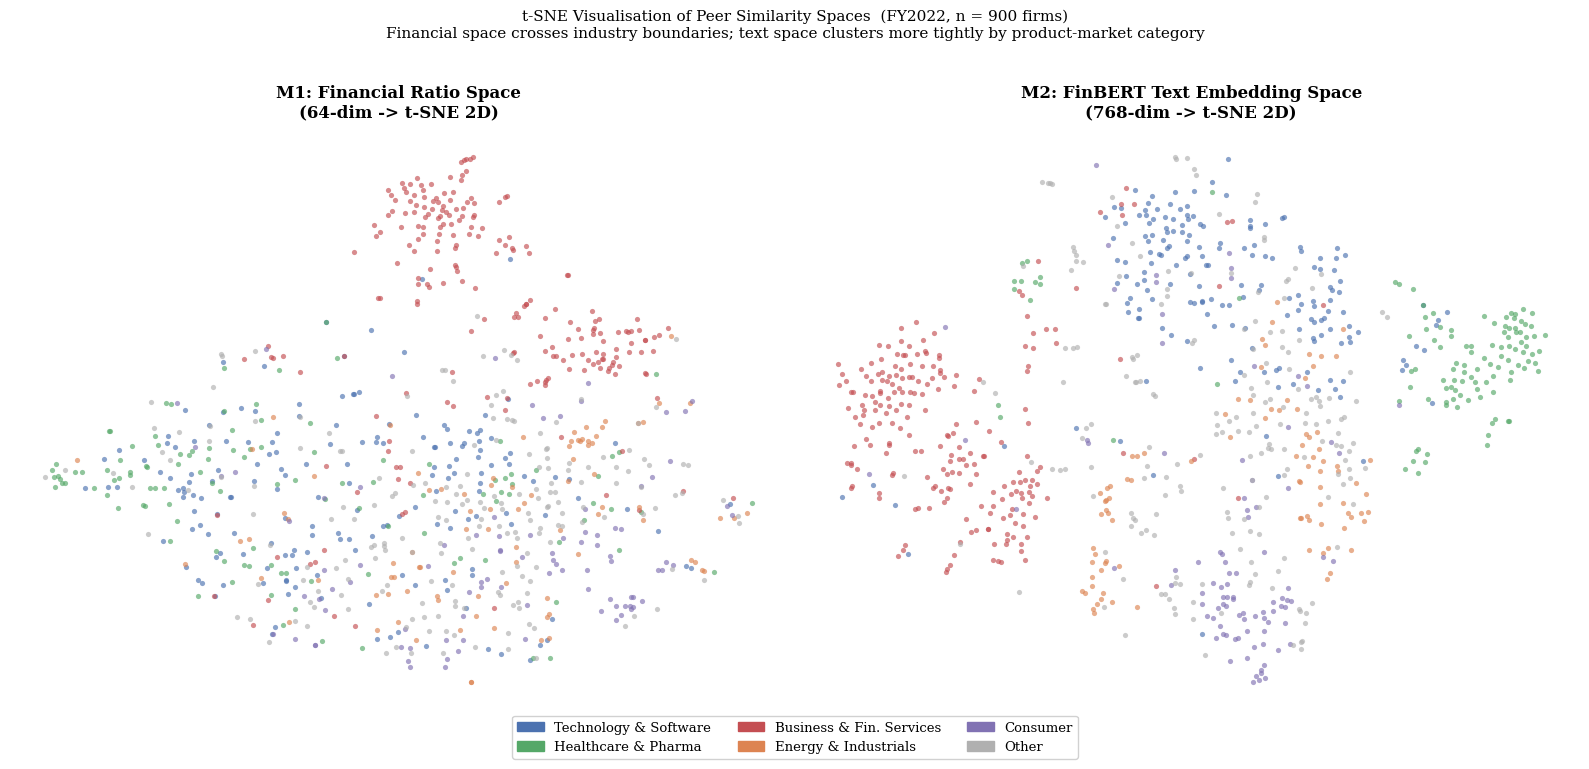

Saved: /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/figures/n10_tsne_embedding_spaces_2022.pdf


In [42]:
# Figure
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
panel_labels = [
    ('M1: Financial Ratio Space\n(64-dim -> t-SNE 2D)',  coords_fin),
    ('M2: FinBERT Text Embedding Space\n(768-dim -> t-SNE 2D)', coords_text),
]

for ax, (title, coords) in zip(axes, panel_labels):
    for sector, color in SECTOR_COLORS.items():
        mask = sectors == sector
        ax.scatter(coords[mask, 0], coords[mask, 1], c=color, s=14, alpha=0.65,
                   linewidths=0, label=sector)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

handles = [mpatches.Patch(color=c, label=s) for s, c in SECTOR_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=3,
           fontsize=9.5, framealpha=0.9, bbox_to_anchor=(0.5, -0.06))
fig.suptitle(f't-SNE Visualisation of Peer Similarity Spaces  '
             f'(FY{TSNE_YEAR}, n = {n} firms)\n'
             'Financial space crosses industry boundaries; '
             'text space clusters more tightly by product-market category',
             fontsize=11, y=1.02)
plt.tight_layout()
save_path = FIGURES / f'n10_tsne_embedding_spaces_{TSNE_YEAR}.pdf'
plt.savefig(save_path, dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")


In [43]:
# ══════════════════════════════════════════════════════════════════════════════
# t-SNE COMPANION — Quantitative sector separation metrics
# Computed on original high-dim vectors (not t-SNE reduction)
# M1: StandardScaler-normalised 64-dim financial features
# M2: L2-normalised 768-dim FinBERT embeddings
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
sector_labels = le.fit_transform(sectors)
sector_names  = le.classes_

# ── Overall silhouette scores ─────────────────────────────────────────────────
sil_fin_overall  = silhouette_score(fin_scaled, sector_labels, metric="euclidean")
sil_text_overall = silhouette_score(emb_mat,    sector_labels, metric="euclidean")
print(f"Overall silhouette — M1 Financial : {sil_fin_overall:.4f}")
print(f"Overall silhouette — M2 Text      : {sil_text_overall:.4f}")

# ── Per-sector silhouette scores ──────────────────────────────────────────────
sil_fin_samples  = silhouette_samples(fin_scaled, sector_labels, metric="euclidean")
sil_text_samples = silhouette_samples(emb_mat,    sector_labels, metric="euclidean")

records_sil = []
for s, name in enumerate(sector_names):
    mask = sector_labels == s
    records_sil.append({
        "sector":   name,
        "n":        mask.sum(),
        "sil_fin":  sil_fin_samples[mask].mean(),
        "sil_text": sil_text_samples[mask].mean(),
    })

sil_df = pd.DataFrame(records_sil).sort_values("sil_text", ascending=False)
print("\nPer-sector silhouette scores:")
print(sil_df.to_string(index=False))

Overall silhouette — M1 Financial : -0.0298
Overall silhouette — M2 Text      : 0.0701

Per-sector silhouette scores:
                  sector   n   sil_fin  sil_text
Business & Fin. Services 223  0.067715  0.149355
     Healthcare & Pharma 115 -0.179808  0.133058
   Technology & Software 178 -0.060410  0.085594
                Consumer  94 -0.003237  0.068540
    Energy & Industrials  91  0.058393  0.040167
                   Other 199 -0.077869 -0.054544


In [44]:
# ── Per-sector within/between distance ratio ──────────────────────────────────
# ratio = mean_within / mean_between  →  lower = tighter cluster

def wb_ratio(X, labels, target_label):
    mask = labels == target_label
    X_in  = X[mask]
    X_out = X[~mask]
    if len(X_in) < 2 or len(X_out) < 2:
        return np.nan
    # sample for speed if large
    if len(X_in) > 200:
        idx = np.random.choice(len(X_in), 200, replace=False)
        X_in = X_in[idx]
    if len(X_out) > 200:
        idx = np.random.choice(len(X_out), 200, replace=False)
        X_out = X_out[idx]
    from sklearn.metrics import pairwise_distances
    within  = pairwise_distances(X_in,         metric="euclidean").mean()
    between = pairwise_distances(X_in, X_out,  metric="euclidean").mean()
    return within / between

records_wb = []
for s, name in enumerate(sector_names):
    records_wb.append({
        "sector":   name,
        "n":        (sector_labels == s).sum(),
        "wb_fin":   wb_ratio(fin_scaled, sector_labels, s),
        "wb_text":  wb_ratio(emb_mat,    sector_labels, s),
    })

wb_df = pd.DataFrame(records_wb).sort_values("wb_text")
print("Per-sector within/between ratio (lower = tighter cluster):")
print(wb_df.to_string(index=False))

Per-sector within/between ratio (lower = tighter cluster):
                  sector   n   wb_fin  wb_text
Business & Fin. Services 223 0.813922 0.796037
     Healthcare & Pharma 115 1.112260 0.798045
   Technology & Software 178 0.948196 0.829190
                Consumer  94 0.901486 0.847421
    Energy & Industrials  91 0.851753 0.867445
                   Other 199 0.962808 0.932817


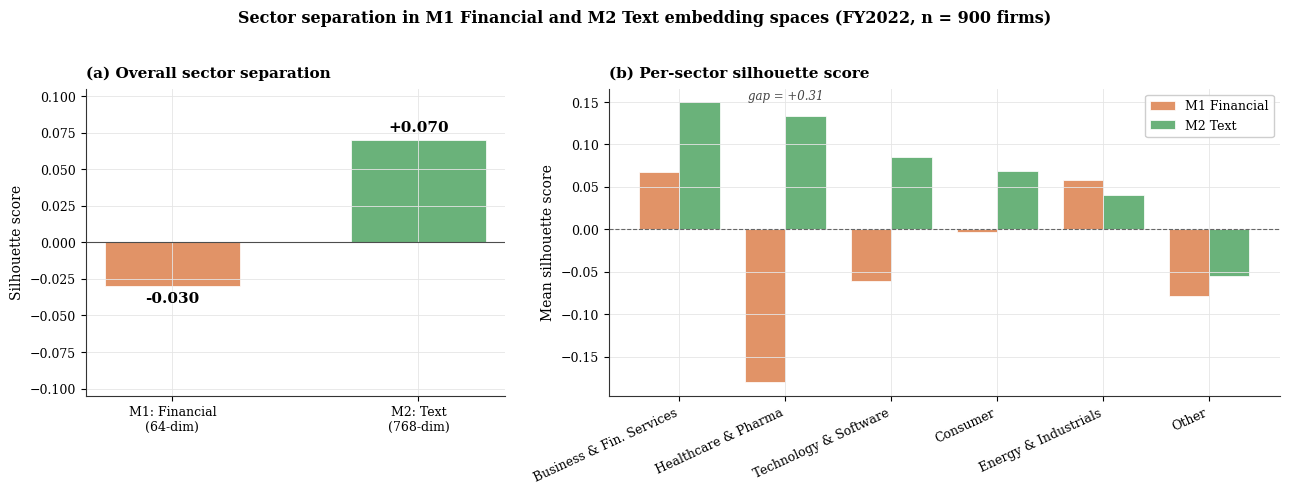

Saved → /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/figures/n10_tsne_sector_separation_2022.pdf


In [45]:
# ── Plot: companion figure to t-SNE (paper version, 2 panels) ────────────────
# OUTPUTS = [FIGURES / "n10_tsne_sector_separation.pdf"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8),
                          gridspec_kw={'width_ratios': [1, 1.6]})

# ── Panel 1: Overall silhouette bar ───────────────────────────────────────────
ax = axes[0]
vals   = [sil_fin_overall, sil_text_overall]
labels = ["M1: Financial\n(64-dim)", "M2: Text\n(768-dim)"]
colors = [MODEL_COLORS["M1_Financial"], MODEL_COLORS["M2_Text"]]
bars   = ax.bar(labels, vals, color=colors, width=0.55, alpha=0.88,
                edgecolor='white', linewidth=0.6)

for bar, val in zip(bars, vals):
    va  = "bottom" if val >= 0 else "top"
    y   = val + 0.004 if val >= 0 else val - 0.004
    ax.text(bar.get_x() + bar.get_width() / 2, y,
            f"{val:+.3f}", ha="center", va=va, fontsize=11,
            fontweight="bold")

ax.axhline(0, color="0.3", lw=0.8)
yabs = max(abs(sil_fin_overall), abs(sil_text_overall))
ax.set_ylim(-yabs * 1.5, yabs * 1.5)
ax.set_ylabel("Silhouette score", fontsize=10)
ax.set_title("(a) Overall sector separation", fontsize=11,
             fontweight='bold', loc="left", pad=8)
ax.tick_params(labelsize=9)
sns.despine(ax=ax)

# ── Panel 2: Per-sector silhouette grouped bar ────────────────────────────────
ax = axes[1]
x    = np.arange(len(sil_df))
w    = 0.38
b1   = ax.bar(x - w/2, sil_df["sil_fin"],  width=w,
              color=MODEL_COLORS["M1_Financial"], alpha=0.88,
              edgecolor='white', linewidth=0.6, label="M1 Financial")
b2   = ax.bar(x + w/2, sil_df["sil_text"], width=w,
              color=MODEL_COLORS["M2_Text"],      alpha=0.88,
              edgecolor='white', linewidth=0.6, label="M2 Text")

# Annotate the largest gap (Healthcare & Pharma) since the body prose
# discusses it specifically
for i, (sf, st) in enumerate(zip(sil_df["sil_fin"], sil_df["sil_text"])):
    gap = st - sf
    if abs(gap) == abs(sil_df["sil_text"] - sil_df["sil_fin"]).max():
        y_top = max(sf, st) + 0.02
        ax.annotate(f'gap = {gap:+.2f}', xy=(i, y_top), ha='center',
                    fontsize=8.5, fontstyle='italic', color='#444444')

ax.axhline(0, color="0.4", lw=0.8, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(sil_df["sector"], rotation=25, ha="right", fontsize=9)
ax.set_ylabel("Mean silhouette score", fontsize=10)
ax.set_title("(b) Per-sector silhouette score", fontsize=11,
             fontweight='bold', loc="left", pad=8)
ax.legend(fontsize=9, loc='upper right', frameon=True, framealpha=0.95)
ax.tick_params(axis='y', labelsize=9)
sns.despine(ax=ax)

fig.suptitle(
    f"Sector separation in M1 Financial and M2 Text embedding spaces "
    f"(FY{TSNE_YEAR}, n = {n} firms)",
    fontsize=11.5, fontweight='bold', y=1.02
)
plt.tight_layout()
out = FIGURES / f"n10_tsne_sector_separation_{TSNE_YEAR}.pdf"
fig.savefig(out, dpi=FIGURE_DPI, format=FIGURE_FORMAT, bbox_inches="tight")
plt.show()
print(f"Saved → {out}")

Text Analytics

AI / digital-transformation narrative diffusion in 10-K summaries:
       n_summaries  pct_with_ai  mean_hits  median_hits
fyear                                                  
2020          2446        10.18       0.17          0.0
2021          2781        13.56       0.23          0.0
2022          2717        14.50       0.25          0.0
2023          2742        14.92       0.27          0.0
2024          2873        20.19       0.43          0.0

Top term counts by year:
fyear                    2020  2021  2022  2023  2024
artificial intelligence    58    96    87   104   201
machine learning          110   159   151   158   182
llm                       126   141   159   154   180
data-driven                70    96   117   108   136
ai-powered                 13    37    40    47   127
ai-driven                  16    49    46    53   115
generative ai               0     1     0    14    78
digital transformation     47    76    75    76    77


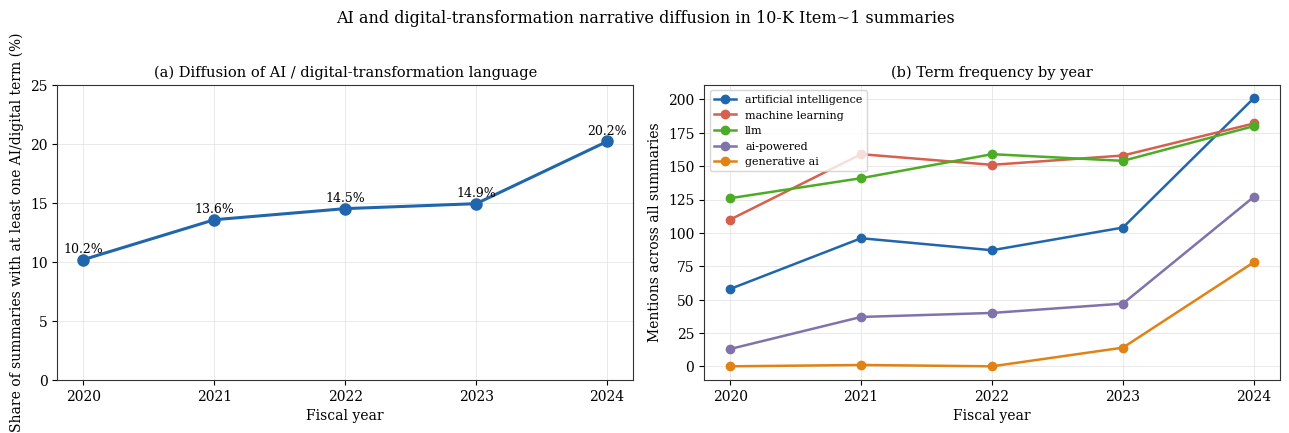

In [46]:
# ── AI/digital-transformation narrative diffusion check ──────────────────────
import pandas as pd
import re

AI_LEXICON = [
    'artificial intelligence', 'machine learning', 'deep learning',
    'generative ai', 'large language model', 'llm',
    'neural network', 'ai-powered', 'ai-driven', 'ai-enabled',
    'digital transformation', 'cloud-native', 'data-driven',
    'predictive analytics', 'automation platform',
]

# Build regex with word boundaries
ai_pattern = re.compile(
    r'\b(' + '|'.join(re.escape(t) for t in AI_LEXICON) + r')\b',
    flags=re.IGNORECASE
)

# Load all summaries
summaries = []
for yr in range(2020, 2025):
    df = pd.read_csv(SUMMARIES_FILES[yr])
    df = df[df['business_description'].notna() &
            (df['business_description'].str.len() > 50)]
    df['fyear'] = yr
    summaries.append(df[['tic', 'fyear', 'business_description']])
summaries = pd.concat(summaries, ignore_index=True)

# Count AI-lexicon hits per summary
summaries['ai_hits'] = summaries['business_description'].apply(
    lambda t: len(ai_pattern.findall(t))
)
summaries['has_ai'] = summaries['ai_hits'] > 0

# Aggregate by year
ai_diffusion = (summaries
                .groupby('fyear')
                .agg(n_summaries   = ('tic',     'count'),
                     pct_with_ai   = ('has_ai',  lambda x: x.mean() * 100),
                     mean_hits     = ('ai_hits', 'mean'),
                     median_hits   = ('ai_hits', 'median'))
                .round(2))

print('AI / digital-transformation narrative diffusion in 10-K summaries:')
print(ai_diffusion.to_string())

# Optional: which terms drive the trend?
term_by_year = []
for yr in range(2020, 2025):
    sub = summaries[summaries['fyear'] == yr]['business_description']
    counts = {term: sub.str.contains(term, case=False, regex=False).sum()
              for term in AI_LEXICON}
    term_by_year.append({'fyear': yr, **counts})
term_df = pd.DataFrame(term_by_year).set_index('fyear')
print('\nTop term counts by year:')
print(term_df.T.sort_values(by=2024, ascending=False).head(8).to_string())

ai_diffusion.to_csv(DATA_RESULTS / 'ai_narrative_diffusion.csv')

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# ── Left panel: share of summaries with AI language ──────────────────────────
ax = axes[0]
years = ai_diffusion.index.tolist()
ax.plot(years, ai_diffusion['pct_with_ai'], marker='o', linewidth=2.2,
        color='#2166ac', markersize=8)
for yr, val in zip(years, ai_diffusion['pct_with_ai']):
    ax.text(yr, val + 0.6, f'{val:.1f}%', ha='center', fontsize=9)
ax.set_xlabel('Fiscal year')
ax.set_ylabel('Share of summaries with at least one AI/digital term (%)')
ax.set_title('(a) Diffusion of AI / digital-transformation language',
             fontsize=10.5)
ax.set_xticks(years)
ax.set_ylim(0, 25)

# ── Right panel: top terms over time ─────────────────────────────────────────
ax = axes[1]
top_terms = ['artificial intelligence', 'machine learning', 'llm',
             'ai-powered', 'generative ai']
colors = ['#2166ac', '#d6604d', '#4dac26', '#8073ac', '#e08214']
for term, c in zip(top_terms, colors):
    counts = [term_df.loc[yr, term] for yr in years]
    ax.plot(years, counts, marker='o', linewidth=1.8, label=term,
            color=c, markersize=6)
ax.set_xlabel('Fiscal year')
ax.set_ylabel('Mentions across all summaries')
ax.set_title('(b) Term frequency by year', fontsize=10.5)
ax.legend(fontsize=8, loc='upper left')
ax.set_xticks(years)

fig.suptitle('AI and digital-transformation narrative diffusion in 10-K Item~1 summaries',
             fontsize=11.5, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'ai_narrative_diffusion.pdf', dpi=FIGURE_DPI,
            bbox_inches='tight')
plt.show()

## 11. Save Results and Final Summary

In [47]:
# Save master results CSV
RESULTS_MAIN.parent.mkdir(parents=True, exist_ok=True)
results_df['run_date'] = pd.Timestamp.now().strftime('%Y-%m-%d')
results_df['status']   = 'complete'
results_df.to_csv(RESULTS_MAIN, index=False)
print(f"Saved: {RESULTS_MAIN}")
print(f"Rows : {len(results_df)}")


Saved: /content/drive/MyDrive/Masterarbeit/3. Data Zone/archive-8704040-04-18-2026 (Unzipped Files)/Repo/data/results/results_main.csv
Rows : 60


In [48]:
# Final summary print
print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)
print(f"Evaluation sample: {len(summary_tickers):,} firm-years  "
      f"({multiples['tic'].nunique():,} unique firms)")
print(f"Primary metric  : MdAPE on ln(EV/Sales), k={K_MAIN}")
print(f"Validation years: {VALIDATION_YEARS}")
print(f"Test years      : {TEST_YEARS}")
print()

for model_name in ['M0_FF49','M1_Financial','M2_Text','M3_Fusion']:
    row = results_df[(results_df['model']==model_name) &
                     (results_df['multiple']=='ln_v2s') &
                     (results_df['k']==K_MAIN)].iloc[0]
    print(f"  {MODEL_LABELS[model_name]:<28} "
          f"MdAPE={row['mdape']*100:.2f}%  "
          f"[{row['ci_lo']*100:.2f}%, {row['ci_hi']*100:.2f}%]")

m0 = results_df[(results_df['model']=='M0_FF49') &
                (results_df['multiple']=='ln_v2s') &
                (results_df['k']==K_MAIN)]['mdape'].values[0]
m3 = results_df[(results_df['model']=='M3_Fusion') &
                (results_df['multiple']=='ln_v2s') &
                (results_df['k']==K_MAIN)]['mdape'].values[0]

print(f"\n  Total improvement M0 -> M3 : {(m0-m3)/m0*100:+.1f}%")
print(f"  Optimal alpha (M3)         : {alpha_info['best_alpha']}")
print(f"  Fusion method              : Weighted Rank (+ RRF robustness check)")
print(f"\nAll hypothesis tests (H1, H2, H3): see Section 4.")
print(f"Sector-level diagnostics (Section 6) support discussion only; "
      f"no formal H4 test.")


FINAL RESULTS SUMMARY
Evaluation sample: 13,559 firm-years  (5,699 unique firms)
Primary metric  : MdAPE on ln(EV/Sales), k=10
Validation years: [2020, 2021, 2022]
Test years      : [2023, 2024]

  M0: FF49 Baseline            MdAPE=54.79%  [53.50%, 56.20%]
  M1: Financial kNN            MdAPE=43.75%  [42.57%, 44.57%]
  M2: Text kNN (FinBERT)       MdAPE=51.89%  [50.86%, 53.08%]
  M3: Late Fusion              MdAPE=41.13%  [40.22%, 41.99%]

  Total improvement M0 -> M3 : +24.9%
  Optimal alpha (M3)         : 0.3
  Fusion method              : Weighted Rank (+ RRF robustness check)

All hypothesis tests (H1, H2, H3): see Section 4.
Sector-level diagnostics (Section 6) support discussion only; no formal H4 test.


In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# Systematic case study finder — 2024, role-balanced
# Scores every (focal_tic, fyear) in the eval sample on a multi-role rubric,
# filters to recognisable firms, and surfaces the best candidate per role.
# ─────────────────────────────────────────────────────────────────────────────

CASE_YEAR = 2024
K_VAL     = K_MAIN

# Curated recognisable-firms universe (edit freely — seeded with ~110 names
# spanning FF49 sectors, weighted toward firms a thesis reader will recognise)
RECOGNISABLE_TICKERS = {
    # Mega-cap tech / platform
    'AAPL', 'MSFT', 'GOOGL', 'GOOG', 'AMZN', 'META', 'NVDA', 'TSLA', 'NFLX',
    'ADBE', 'CRM', 'ORCL', 'INTC', 'AMD', 'QCOM', 'AVGO', 'CSCO', 'IBM',
    'TXN', 'MU', 'AMAT', 'LRCX', 'PYPL', 'SHOP', 'UBER', 'ABNB', 'SPOT',
    'SNAP', 'PINS', 'SQ', 'ROKU', 'ZM', 'DOCU', 'CRWD', 'PANW', 'NOW',
    'SNOW', 'DDOG', 'NET', 'PLTR',
    # Pharma / biotech / health
    'JNJ', 'PFE', 'MRK', 'ABBV', 'LLY', 'BMY', 'AMGN', 'GILD', 'BIIB',
    'REGN', 'VRTX', 'MRNA', 'CVS', 'UNH', 'CI', 'HUM', 'ANTM', 'HCA',
    # Financial
    'JPM', 'BAC', 'WFC', 'C', 'GS', 'MS', 'BLK', 'SCHW', 'AXP', 'V', 'MA',
    'COF', 'USB', 'PNC', 'TFC', 'BK', 'STT',
    # Energy
    'XOM', 'CVX', 'COP', 'OXY', 'EOG', 'PSX', 'VLO', 'MPC', 'SLB', 'HAL',
    # Consumer / retail
    'WMT', 'COST', 'TGT', 'HD', 'LOW', 'NKE', 'SBUX', 'MCD', 'YUM', 'CMG',
    'KO', 'PEP', 'PG', 'CL', 'KMB', 'MDLZ', 'GIS', 'K', 'EL', 'LULU',
    'TJX', 'ROST', 'BBY', 'DG', 'DLTR', 'KR', 'WBA',
    # Industrial / autos / aerospace
    'BA', 'GE', 'CAT', 'DE', 'HON', 'MMM', 'LMT', 'RTX', 'NOC', 'GD',
    'F', 'GM', 'STLA', 'UPS', 'FDX', 'CSX', 'UNP', 'NSC',
    # Media / entertainment / telecom
    'DIS', 'CMCSA', 'T', 'VZ', 'TMUS', 'WBD', 'PARA',
    # Utilities / REITs (light coverage)
    'NEE', 'DUK', 'SO', 'AMT', 'PLD', 'SPG',
}

# ─── Step 1: build per-firm-year APE table for all four models ──────────────
def ape_table(peers_df, multiples_df, model_name, k=K_VAL,
              multiple_col='ln_v2s'):
    p = peers_df[peers_df['rank'] <= k].copy()
    mult = multiples_df[['tic', 'fyear', multiple_col]].rename(
        columns={'tic': 'peer_tic', multiple_col: 'peer_mult'})
    p = p.merge(mult, left_on=['peer_tic', 'focal_fyear'],
                right_on=['peer_tic', 'fyear'], how='left')
    implied = (p.groupby(['focal_tic', 'focal_fyear'])['peer_mult']
                .median().reset_index().rename(columns={'peer_mult': 'implied_ln'}))

    actual = multiples_df[['tic', 'fyear', multiple_col]].rename(
        columns={'tic': 'focal_tic', 'fyear': 'focal_fyear',
                 multiple_col: 'actual_ln'})
    out = implied.merge(actual, on=['focal_tic', 'focal_fyear'], how='inner')
    out['actual_mult']  = np.exp(out['actual_ln'])
    out['implied_mult'] = np.exp(out['implied_ln'])
    out['ape']          = (out['actual_mult'] - out['implied_mult']).abs() / \
                          out['actual_mult'].abs() * 100
    out['signed_gap']   = (out['implied_mult'] - out['actual_mult']) / \
                          out['actual_mult'].abs() * 100
    return out[['focal_tic', 'focal_fyear', 'actual_mult',
                'implied_mult', 'ape', 'signed_gap']].rename(
        columns={'ape': f'{model_name}_ape',
                 'implied_mult': f'{model_name}_implied',
                 'signed_gap': f'{model_name}_signed'})

ape_m0 = ape_table(peers_m0, multiples, 'M0')
ape_m1 = ape_table(peers_m1, multiples, 'M1')
ape_m2 = ape_table(peers_m2, multiples, 'M2')
ape_m3 = ape_table(peers_m3, multiples, 'M3')

scores = (ape_m0
          .merge(ape_m1[['focal_tic', 'focal_fyear', 'M1_implied',
                         'M1_ape', 'M1_signed']],
                 on=['focal_tic', 'focal_fyear'])
          .merge(ape_m2[['focal_tic', 'focal_fyear', 'M2_implied',
                         'M2_ape', 'M2_signed']],
                 on=['focal_tic', 'focal_fyear'])
          .merge(ape_m3[['focal_tic', 'focal_fyear', 'M3_implied',
                         'M3_ape', 'M3_signed']],
                 on=['focal_tic', 'focal_fyear']))

# ─── Step 2: filter to recognisable firms in CASE_YEAR ──────────────────────
yr = scores[(scores['focal_fyear'] == CASE_YEAR) &
            (scores['focal_tic'].isin(RECOGNISABLE_TICKERS))].copy()

# Attach industry
ind = (df_panel[df_panel['fyear'] == CASE_YEAR]
       [['tic', 'ff49_num', 'industry']]
       .drop_duplicates('tic'))
yr = yr.merge(ind, left_on='focal_tic', right_on='tic', how='left').drop(columns='tic')

print(f"Recognisable firms with valid evaluation in FY{CASE_YEAR}: {len(yr)}")

# ─── Step 3: score each firm on six narrative roles ─────────────────────────
def score_roles(d):
    d = d.copy()
    best_ape = d[['M0_ape', 'M1_ape', 'M2_ape', 'M3_ape']].min(axis=1)
    d['m3_is_best']     = (d['M3_ape'] == best_ape)
    d['m1_is_best']     = (d['M1_ape'] == best_ape)
    d['m2_is_best']     = (d['M2_ape'] == best_ape)
    d['m0_is_best']     = (d['M0_ape'] == best_ape)

    # Role 1 — Multimodal-outlier: FF49 fails, M3 recovers
    d['role1_score'] = np.where(
        (d['M0_ape'] > 50) & (d['M3_ape'] < 25) & d['m3_is_best'],
        d['M0_ape'] - d['M3_ape'], np.nan)

    # Role 2 — Financial-dominant: M1 best, M3 close behind
    d['role2_score'] = np.where(
        (d['M1_ape'] < 15) & d['m1_is_best'] &
        (d['M1_ape'] < d['M2_ape'] - 10),
        (d['M0_ape'] - d['M1_ape']) - d['M1_ape'], np.nan)

    # Role 3 — Text-dominant: M2 beats M1 by wide margin
    d['role3_score'] = np.where(
        (d['M2_ape'] < 20) & d['m2_is_best'] &
        (d['M1_ape'] - d['M2_ape'] > 15),
        (d['M1_ape'] - d['M2_ape']) - d['M2_ape'], np.nan)

    # Role 4 — Consensus-reinforcement: M3 < min(M1, M2), all three < M0
    d['role4_score'] = np.where(
        (d['M3_ape'] < d['M1_ape']) & (d['M3_ape'] < d['M2_ape']) &
        (d['M3_ape'] < 20) & (d['M0_ape'] - d['M3_ape'] > 20),
        d['M0_ape'] - d['M3_ape'], np.nan)

    # Role 5 — Baseline-survives: M0 already < 25%, M3 doesn't break it
    d['role5_score'] = np.where(
        (d['M0_ape'] < 25) & (d['M3_ape'] < 25) &
        (abs(d['M3_ape'] - d['M0_ape']) < 10),
        25 - d['M0_ape'], np.nan)

    # Role 6 — Structural-ceiling: all four > 50% (used as scope case)
    d['role6_score'] = np.where(
        d[['M0_ape', 'M1_ape', 'M2_ape', 'M3_ape']].min(axis=1) > 50,
        d[['M0_ape', 'M1_ape', 'M2_ape', 'M3_ape']].min(axis=1), np.nan)
    return d

scored = score_roles(yr)

# ─── Step 4: surface top candidate per role ─────────────────────────────────
ROLE_NAMES = {
    'role1_score': '1. Multimodal-outlier (FF49 fails, M3 recovers)',
    'role2_score': '2. Financial-dominant (M1 already wins)',
    'role3_score': '3. Text-dominant (M2 beats M1 widely)',
    'role4_score': '4. Consensus-reinforcement (M3 < min(M1,M2))',
    'role5_score': '5. Baseline-survives (M0 close, M3 holds)',
    'role6_score': '6. Structural-ceiling (all models miss)',
}

print(f"\n{'='*100}")
print(f"  TOP CANDIDATES PER ROLE  |  FY{CASE_YEAR}  |  k={K_VAL}  |  ln(EV/Sales)")
print(f"{'='*100}")

picks = {}
for role_col, role_label in ROLE_NAMES.items():
    cands = (scored.dropna(subset=[role_col])
             .sort_values(role_col, ascending=False)
             .head(8))
    print(f"\n{role_label}")
    print(f"  {'Tic':<6} {'Industry':<22} "
          f"{'M0%':>7} {'M1%':>7} {'M2%':>7} {'M3%':>7}  Score")
    print(f"  {'-'*70}")
    for _, r in cands.iterrows():
        print(f"  {r['focal_tic']:<6} {str(r['industry'])[:22]:<22} "
              f"{r['M0_ape']:>6.1f} {r['M1_ape']:>6.1f} "
              f"{r['M2_ape']:>6.1f} {r['M3_ape']:>6.1f}  "
              f"{r[role_col]:>6.1f}")
    picks[role_col] = cands.head(3)['focal_tic'].tolist()

# ─── Step 5: build a balanced 6-firm shortlist (one per role, deduped) ──────
shortlist, used = [], set()
for role_col, role_label in ROLE_NAMES.items():
    for tic in picks[role_col]:
        if tic not in used:
            shortlist.append((tic, role_label))
            used.add(tic)
            break

print(f"\n{'='*100}")
print(f"  PROPOSED 6-FIRM SHORTLIST  (one per role, no overlap)")
print(f"{'='*100}")
for tic, role in shortlist:
    row = scored[scored['focal_tic'] == tic].iloc[0]
    name = name_lookup.get(tic, tic)
    print(f"  {tic:<6} {name[:32]:<32}  {row['industry'][:20]:<20}  "
          f"M0={row['M0_ape']:.1f}%  M1={row['M1_ape']:.1f}%  "
          f"M2={row['M2_ape']:.1f}%  M3={row['M3_ape']:.1f}%")
    print(f"          → role: {role}")

# ─── Step 6: feed shortlist back into existing FOCAL_FIRMS / get_case_row ───
SHORTLIST_FOCAL = [(tic, CASE_YEAR, scored[scored['focal_tic']==tic].iloc[0]['industry'])
                   for tic, _ in shortlist]

print(f"\nDrop-in replacement for FOCAL_FIRMS:")
print(f"FOCAL_FIRMS = {SHORTLIST_FOCAL}")

scored.to_csv(DATA_RESULTS / 'case_study_role_scores_2024.csv', index=False)
print(f"\nSaved full scoring table: case_study_role_scores_2024.csv")

Recognisable firms with valid evaluation in FY2024: 121

  TOP CANDIDATES PER ROLE  |  FY2024  |  k=10  |  ln(EV/Sales)

1. Multimodal-outlier (FF49 fails, M3 recovers)
  Tic    Industry                   M0%     M1%     M2%     M3%  Score
  ----------------------------------------------------------------------
  VLO    Petroleum and Natural   412.2   13.6  470.2   12.0   400.2
  PSX    Petroleum and Natural   306.1   23.2   83.8    4.0   302.0
  LMT    Defense                 157.2   25.6   29.2   10.5   146.6
  NOC    Electronic Equipment     83.1    9.1   26.3    6.6    76.5
  HON    Almost Nothing           79.2   18.6   38.8    7.2    72.0
  NSC    Transportation           74.2    2.7   84.5    2.7    71.5
  CSX    Transportation           72.9   15.7   69.3   15.7    57.2
  CL     Consumer Goods           64.4   26.7   30.2   22.1    42.4

2. Financial-dominant (M1 already wins)
  Tic    Industry                   M0%     M1%     M2%     M3%  Score
  -----------------------------

In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# Curated shortlist robustness check — multi-multiple consistency + peer eyeball
# Run AFTER the role-scoring cell. Replaces auto-shortlist with curated picks
# and validates each firm across all three multiples + prints peer lists.
# ─────────────────────────────────────────────────────────────────────────────

CURATED_SHORTLIST = [
    ('HON',  2024, 'Diversified Industrial',     '1. Multimodal-outlier'),
    ('GS',   2024, 'Investment Banking',         '2. Financial-dominant'),
    ('GIS',  2024, 'Packaged Foods',             '3. Text-dominant'),
    ('MDLZ', 2024, 'Packaged Foods',             '4. Consensus-reinforcement'),
    ('DIS',  2024, 'Media & Entertainment',      '5. Baseline-survives'),
    ('NVDA', 2024, 'Semiconductors (singleton)', '6. Structural-ceiling'),
]

# ─── Step 1: multi-multiple robustness ──────────────────────────────────────
def ape_for_multiple(peers_df, multiples_df, model_name, multiple_col, k=K_VAL):
    p = peers_df[peers_df['rank'] <= k].copy()
    mult = multiples_df[['tic', 'fyear', multiple_col]].rename(
        columns={'tic': 'peer_tic', multiple_col: 'peer_mult'})
    p = p.merge(mult, left_on=['peer_tic', 'focal_fyear'],
                right_on=['peer_tic', 'fyear'], how='left')
    implied = (p.groupby(['focal_tic', 'focal_fyear'])['peer_mult']
                 .median().reset_index().rename(columns={'peer_mult': 'implied_ln'}))
    actual = multiples_df[['tic', 'fyear', multiple_col]].rename(
        columns={'tic': 'focal_tic', 'fyear': 'focal_fyear',
                 multiple_col: 'actual_ln'})
    out = implied.merge(actual, on=['focal_tic', 'focal_fyear'], how='inner')
    out[f'{model_name}_ape'] = (np.exp(out['actual_ln']) -
                                 np.exp(out['implied_ln'])).abs() / \
                                np.exp(out['actual_ln']).abs() * 100
    return out[['focal_tic', 'focal_fyear', f'{model_name}_ape']]

print("=" * 100)
print(f"  ROBUSTNESS — APE across all three multiples  |  FY{CASE_YEAR}  |  k={K_VAL}")
print("=" * 100)

for mult_col, mult_label in [('ln_v2s', 'EV/Sales'),
                              ('ln_v2a', 'EV/Assets'),
                              ('ln_m2b', 'MktCap/SEQ')]:
    rows = []
    for model_name, peers_df in ALL_PEERS.items():
        rows.append(ape_for_multiple(peers_df, multiples,
                                     model_name.split('_')[0], mult_col))
    merged = rows[0]
    for r in rows[1:]:
        merged = merged.merge(r, on=['focal_tic', 'focal_fyear'])

    print(f"\n  Multiple: {mult_label}")
    print(f"  {'Tic':<6} {'M0%':>8} {'M1%':>8} {'M2%':>8} {'M3%':>8}  "
          f"{'Best':>6}  Role")
    print(f"  {'-'*82}")
    for tic, yr, _, role in CURATED_SHORTLIST:
        sub = merged[(merged['focal_tic'] == tic) &
                     (merged['focal_fyear'] == yr)]
        if sub.empty:
            print(f"  {tic:<6}  (missing for {mult_label})")
            continue
        r = sub.iloc[0]
        apes = {'M0': r['M0_ape'], 'M1': r['M1_ape'],
                'M2': r['M2_ape'], 'M3': r['M3_ape']}
        best = min(apes, key=apes.get)
        print(f"  {tic:<6} {r['M0_ape']:>7.1f} {r['M1_ape']:>7.1f} "
              f"{r['M2_ape']:>7.1f} {r['M3_ape']:>7.1f}  "
              f"{best:>6}  {role[:35]}")

# ─── Step 2: peer eyeball test (M3 peers per firm) ──────────────────────────
print(f"\n{'='*100}")
print(f"  M3 TOP-10 PEERS — eyeball test")
print(f"{'='*100}")

for tic, yr, label, role in CURATED_SHORTLIST:
    peers = (peers_m3[(peers_m3['focal_tic'] == tic) &
                       (peers_m3['focal_fyear'] == yr) &
                       (peers_m3['rank'] <= 10)]
             .sort_values('rank'))
    name = name_lookup.get(tic, tic)
    print(f"\n  {tic} — {name}  ({label})  | role: {role}")
    for _, p in peers.iterrows():
        peer_name = name_lookup.get(p['peer_tic'], p['peer_tic'])[:30]
        try:
            peer_ind = industry_lookup.loc[
                (p['peer_tic'], yr), 'industry'][:24]
        except KeyError:
            peer_ind = '?'
        print(f"    {int(p['rank']):>2}. {p['peer_tic']:<6} "
              f"{peer_name:<32} {peer_ind}")

# ─── Step 3: drop-in replacement ────────────────────────────────────────────
print(f"\n{'='*100}")
print("  DROP-IN: replace FOCAL_FIRMS with this in your peer-list figure cell")
print(f"{'='*100}")
print("FOCAL_FIRMS = [")
for tic, yr, label, _ in CURATED_SHORTLIST:
    print(f"    ('{tic}', {yr}, '{label}'),")
print("]")

  ROBUSTNESS — APE across all three multiples  |  FY2024  |  k=10

  Multiple: EV/Sales
  Tic         M0%      M1%      M2%      M3%    Best  Role
  ----------------------------------------------------------------------------------
  HON       79.2    18.6    38.8     7.2      M3  1. Multimodal-outlier
  GS        94.8     9.2    56.2    20.7      M1  2. Financial-dominant
  GIS       27.7    51.2     4.7     4.7      M2  3. Text-dominant
  MDLZ      37.4    30.9    19.0     6.0      M3  4. Consensus-reinforcement
  DIS       10.7    20.1    43.0     7.9      M3  5. Baseline-survives
  NVDA      83.7    74.2    76.7    77.5      M1  6. Structural-ceiling

  Multiple: EV/Assets
  Tic         M0%      M1%      M2%      M3%    Best  Role
  ----------------------------------------------------------------------------------
  HON       50.3    28.4    30.7    14.4      M3  1. Multimodal-outlier
  GS       200.8   102.7    33.2   102.7      M2  2. Financial-dominant
  GIS        1.7    43.0  

In [51]:
# ─────────────────────────────────────────────────────────────────────────────
# Re-rank with peer-coherence filter
# A case-study candidate must satisfy: M3's top-10 peers come from ≤ 3 FF49
# industries, and the modal FF49 industry holds ≥ 4 of the 10 peers.
# This kills "lucky median" cases where APE is low but peer set is incoherent.
# ─────────────────────────────────────────────────────────────────────────────

K_VAL = K_MAIN

# Build (focal_tic, focal_fyear) → list of peer FF49 codes for M3
peer_ff49 = (peers_m3[peers_m3['rank'] <= K_VAL]
             .merge(df_panel[['tic', 'fyear', 'ff49_num']]
                    .rename(columns={'tic': 'peer_tic',
                                     'fyear': 'focal_fyear',
                                     'ff49_num': 'peer_ff49'}),
                    on=['peer_tic', 'focal_fyear'], how='left'))

coherence = (peer_ff49.groupby(['focal_tic', 'focal_fyear'])
             .agg(n_unique_industries=('peer_ff49', 'nunique'),
                  modal_industry=('peer_ff49',
                                  lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan),
                  modal_count=('peer_ff49',
                               lambda s: s.value_counts().iloc[0] if len(s) else 0))
             .reset_index())

# Attach focal firm's own FF49 to check modal industry contains focal
focal_ind = (df_panel[df_panel['fyear'] == CASE_YEAR]
             [['tic', 'ff49_num']]
             .rename(columns={'tic': 'focal_tic', 'ff49_num': 'focal_ff49'}))
coherence = coherence.merge(focal_ind, on='focal_tic', how='left')
coherence['modal_contains_focal'] = (coherence['modal_industry'] ==
                                      coherence['focal_ff49'])

# Hard filter
coherent = coherence[
    (coherence['focal_fyear'] == CASE_YEAR) &
    (coherence['n_unique_industries'] <= 4) &
    (coherence['modal_count'] >= 4) &
    (coherence['modal_contains_focal'])
]['focal_tic'].tolist()

print(f"Coherent firms in FY{CASE_YEAR}: {len(coherent)} of "
      f"{coherence[coherence['focal_fyear']==CASE_YEAR].shape[0]}")
print(f"Recognisable AND coherent: "
      f"{len([t for t in coherent if t in RECOGNISABLE_TICKERS])}")

# Re-filter the role-scored table
yr_coherent = scored[scored['focal_tic'].isin(coherent)].copy()

print(f"\n{'='*100}")
print(f"  TOP CANDIDATES PER ROLE (peer-coherence-filtered)  |  FY{CASE_YEAR}")
print(f"{'='*100}")

new_picks = {}
for role_col, role_label in ROLE_NAMES.items():
    if role_col == 'role6_score':   # skip structural-ceiling, see note below
        continue
    cands = (yr_coherent.dropna(subset=[role_col])
             .sort_values(role_col, ascending=False)
             .head(8))
    if cands.empty:
        print(f"\n{role_label}\n  (no coherent candidates — relax filter "
              f"or accept narrower role coverage)")
        continue
    print(f"\n{role_label}")
    print(f"  {'Tic':<6} {'Industry':<22} "
          f"{'M0%':>7} {'M1%':>7} {'M2%':>7} {'M3%':>7}")
    print(f"  {'-'*60}")
    for _, r in cands.iterrows():
        print(f"  {r['focal_tic']:<6} {str(r['industry'])[:22]:<22} "
              f"{r['M0_ape']:>6.1f} {r['M1_ape']:>6.1f} "
              f"{r['M2_ape']:>6.1f} {r['M3_ape']:>6.1f}")
    new_picks[role_col] = cands.head(5)['focal_tic'].tolist()

# Auto-shortlist + force-include GS and GIS as confirmed strong cases
shortlist_v2, used = [('GS', '2. Financial-dominant'),
                       ('GIS', '3. Text-dominant')], {'GS', 'GIS'}
for role_col, role_label in ROLE_NAMES.items():
    if role_col in ('role2_score', 'role3_score', 'role6_score'): continue
    for tic in new_picks.get(role_col, []):
        if tic not in used:
            shortlist_v2.append((tic, role_label))
            used.add(tic)
            break

print(f"\n{'='*100}")
print(f"  COHERENCE-FILTERED SHORTLIST")
print(f"{'='*100}")
for tic, role in shortlist_v2:
    sub = scored[scored['focal_tic'] == tic]
    if sub.empty: continue
    r = sub.iloc[0]
    name = name_lookup.get(tic, tic)[:32]
    cohr = coherence[coherence['focal_tic'] == tic].iloc[0]
    print(f"  {tic:<6} {name:<32}  M0={r['M0_ape']:>5.1f}%  "
          f"M1={r['M1_ape']:>5.1f}%  M2={r['M2_ape']:>5.1f}%  "
          f"M3={r['M3_ape']:>5.1f}%  "
          f"|  modal-FF49 holds {int(cohr['modal_count'])}/10")
    print(f"          → {role}")

Coherent firms in FY2024: 994 of 2873
Recognisable AND coherent: 36

  TOP CANDIDATES PER ROLE (peer-coherence-filtered)  |  FY2024

1. Multimodal-outlier (FF49 fails, M3 recovers)
  Tic    Industry                   M0%     M1%     M2%     M3%
  ------------------------------------------------------------
  CSX    Transportation           72.9   15.7   69.3   15.7

2. Financial-dominant (M1 already wins)
  Tic    Industry                   M0%     M1%     M2%     M3%
  ------------------------------------------------------------
  CVX    Petroleum and Natural    30.3    0.5   11.3    0.5
  COP    Petroleum and Natural    30.2    0.9   19.8   13.1

3. Text-dominant (M2 beats M1 widely)
  Tic    Industry                   M0%     M1%     M2%     M3%
  ------------------------------------------------------------
  OXY    Petroleum and Natural    30.3   28.0    1.6    1.6
  DUK    Utilities                15.5   26.0   10.9   13.9

4. Consensus-reinforcement (M3 < min(M1,M2))
  Tic    Ind